In [1]:
# test new rule of thumb? e.g. const sigmaD
# optimize sigmaS and sigmaD per snapshot for rank 10, 20, 30, 50, 100

In [2]:
from scipy.optimize import minimize
from scipy.optimize import direct, Bounds
from smooth_POD_ROM.post_processing import richardson_lucy
from smooth_POD_ROM.pre_processing import smoothen_rowwise
from smooth_POD_ROM.initial_conditions import rectangular_pulse, rect_pulse_sin, saw_tooth, triangle
from smooth_POD_ROM.reduced_order_model import optimize_hyperparameters, target_function
from smooth_POD_ROM.reduced_order_model import get_data_rw, train_ROM_rw, L2_error_rw, get_predictions, get_improvement
import numpy as np
from smooth_POD_ROM.post_processing import get_sigma
import matplotlib.pyplot as plt
from datetime import datetime

In [3]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import colormaps
from matplotlib.ticker import FormatStrFormatter
cmap = colormaps["viridis"]
page_width_pt = 455.24
pt2in = 0.01389 
pt2cm = 0.0352777778
cm2in = 1/2.54
page_width_cm = 13.70499
# TODO: work with textwidth
plot_width_in = page_width_pt*pt2in/2
page_width_in = page_width_cm*cm2in
print(plot_width_in/cm2in)

fs = 10
fs_lbl = 6
plt.rcParams["figure.figsize"] = (plot_width_in, plot_width_in/1.61803398875)
plt.rcParams["figure.autolayout"] = True
plt.rcParams['font.size'] = fs
plt.rcParams['axes.titlesize'] = fs
plt.rcParams['axes.labelsize'] = fs
plt.rcParams['xtick.labelsize'] = fs
plt.rcParams['ytick.labelsize'] = fs
plt.rcParams['legend.labelspacing'] = 0.0
plt.rcParams['legend.fontsize'] = fs_lbl
plt.rcParams['legend.handlelength'] = 1.0

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=fs, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 45

8.030570172000001


In [4]:
n_x = 1000
x = np.linspace(0, 1, n_x, endpoint=False)
case = {
    "n_x": n_x,
    "shape": x.shape,
    "x": x,
    "dx": x[1] - x[0],

    "n_train": 10,
    "n_test": 10,
    "n_val": 900,  # n_x * (n_train-1)/n_train
    "g": saw_tooth, #rectangular_pulse,
    "truncate": 12,
    "sigma": 0.08,

    "c": 1,
    "monitor_progress_postprocessing": False,
    "num_iter": 100,
    "monitor_convergence": False,
}

In [5]:
del case["n_test"]
RAND = True

0.005000000000000001 0.15000000000000002
[[0.00570483]
 [0.60473328]
 [0.29729287]
 [0.29430628]
 [0.26270413]
 [0.33399959]
 [0.09749581]
 [0.24735489]
 [0.18215844]
 [0.82480859]]
[[0.05477522]
 [0.81339809]
 [0.2186094 ]
 [0.63800296]
 [0.70523244]
 [0.15122565]
 [0.14194749]
 [0.52423038]
 [0.02913778]
 [0.75110444]]


C:\Users\florianma\AppData\Local\Temp\ipykernel_33812\2111327673.py:7: RuntimeWarning: divide by zero encountered in divide
  errors = np.empty((5, 10, nsS, nsD))/0
C:\Users\florianma\AppData\Local\Temp\ipykernel_33812\2111327673.py:7: RuntimeWarning: invalid value encountered in divide
  errors = np.empty((5, 10, nsS, nsD))/0
C:\Repos\POD-ROM-and-gaussian-convolution\src\smooth_POD_ROM\post_processing.py:32: UserWarning: image needs to be 2D
  warnings.warn("image needs to be 2D")


100, 0.12550000, 5.00000000, 0.16010954, 0.13919400, 0.11344145, -29.1476
100, 0.20850000, 5.00000000, 0.16010954, 0.14449716, 0.13477117, -15.8256
100, 0.04250000, 5.00000000, 0.16010954, 0.13075537, 0.10264372, -35.8916
100, 0.12550000, 8.33333333, 0.16010954, 0.13919400, 0.12239207, -23.5573
100, 0.12550000, 1.66666667, 0.16010954, 0.13919400, 0.08276681, -48.3061
100, 0.20850000, 1.66666667, 0.16010954, 0.14449716, 0.11776532, -26.4470
100, 0.04250000, 1.66666667, 0.16010954, 0.13075537, 0.12827553, -19.8826
100, 0.20850000, 8.33333333, 0.16010954, 0.14449716, 0.14534352, -9.2224
100, 0.04250000, 8.33333333, 0.16010954, 0.13075537, 0.07649231, -52.2250
100, 0.15316667, 1.66666667, 0.16010954, 0.14139540, 0.09320644, -41.7858
100, 0.09783333, 1.66666667, 0.16010954, 0.13635545, 0.07921737, -50.5230
100, 0.12550000, 2.77777778, 0.16010954, 0.13919400, 0.08567829, -46.4877
100, 0.12550000, 0.55555556, 0.16010954, 0.13919400, 0.09846623, -38.5007
100, 0.07016667, 8.33333333, 0.16010954

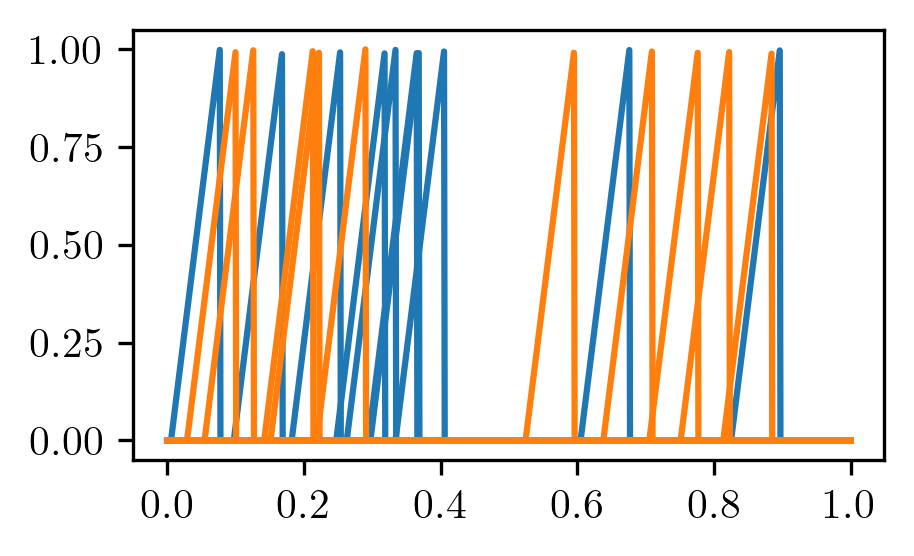

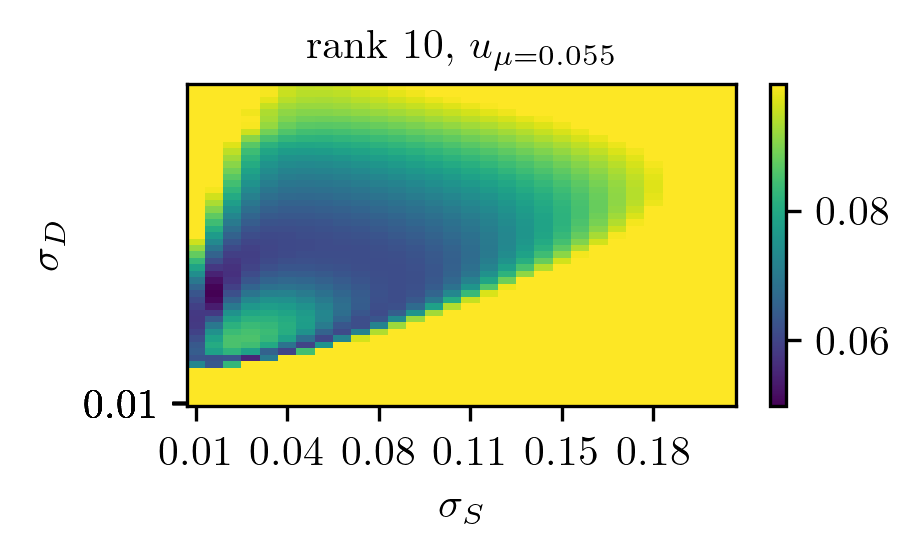

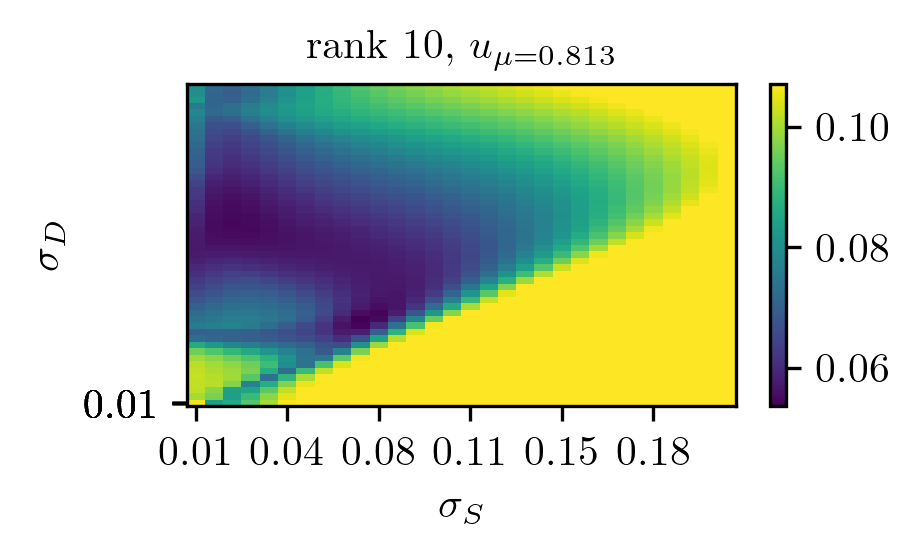

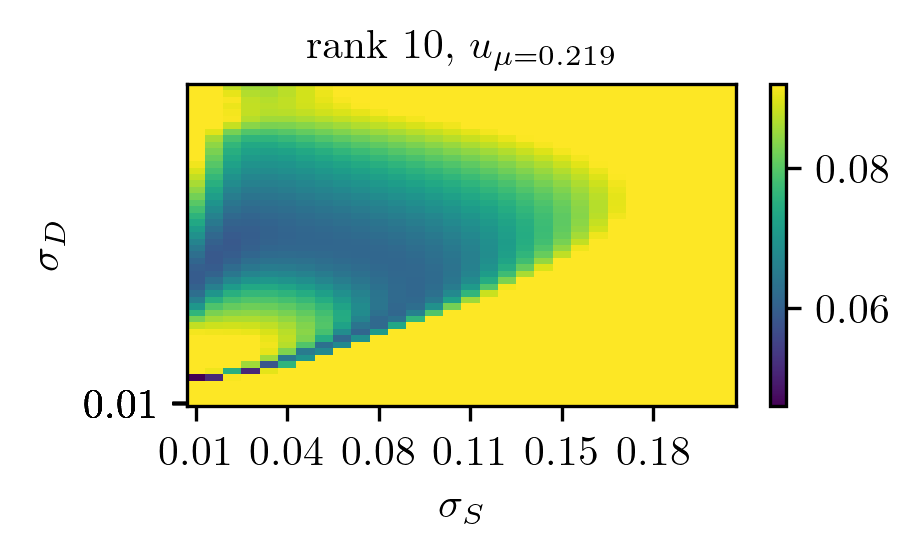

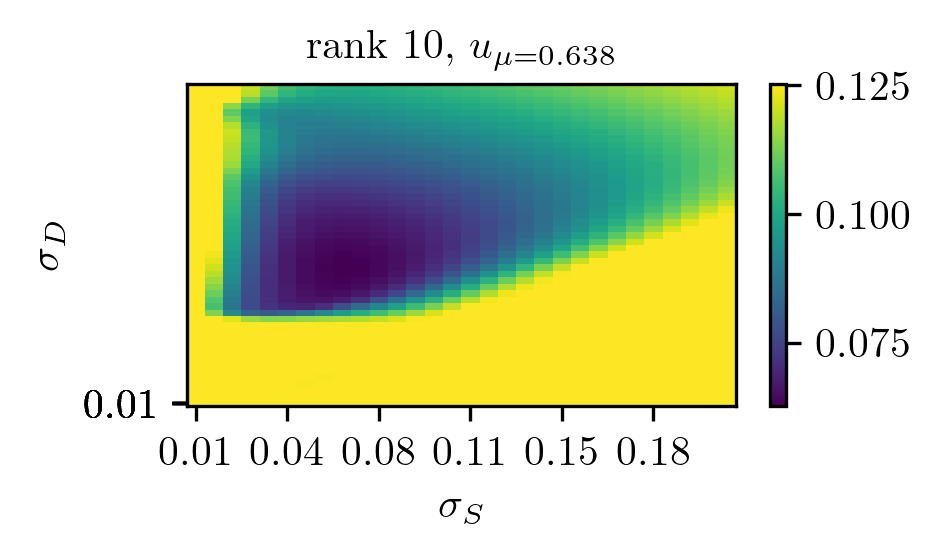

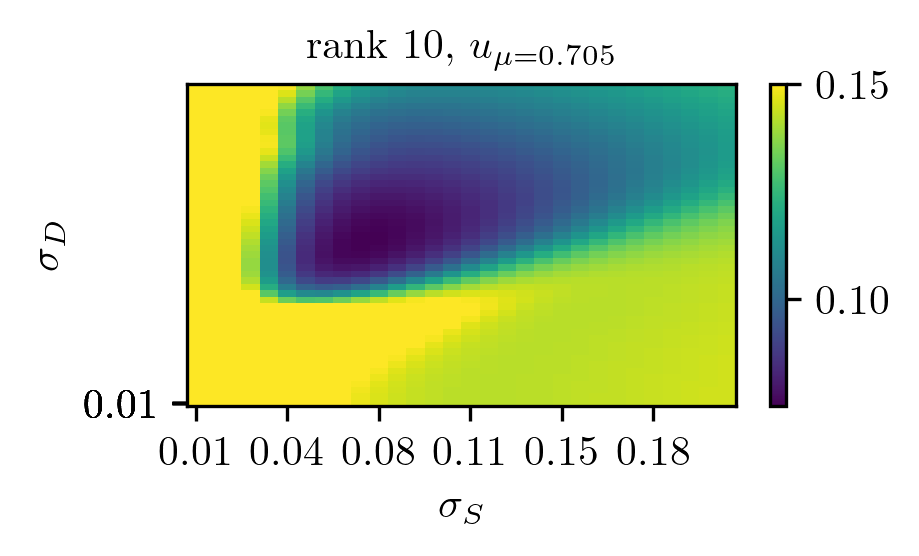

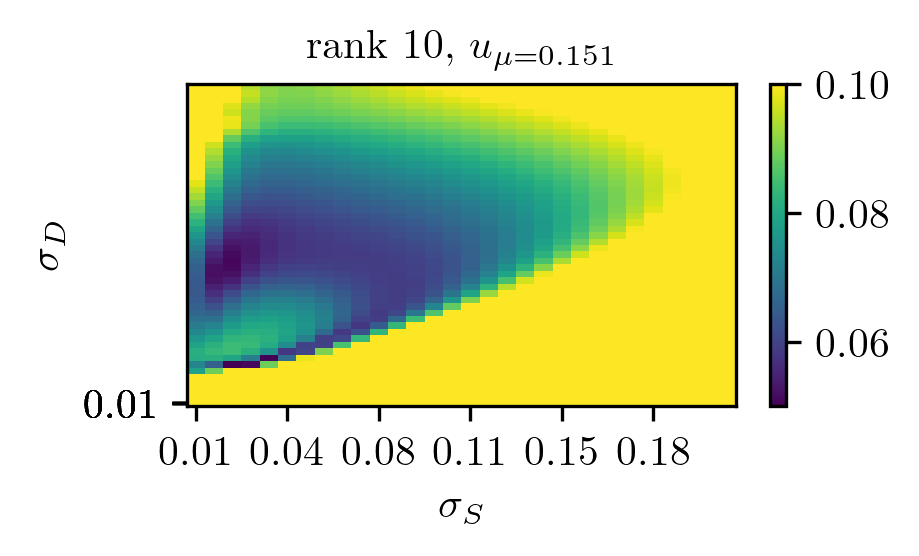

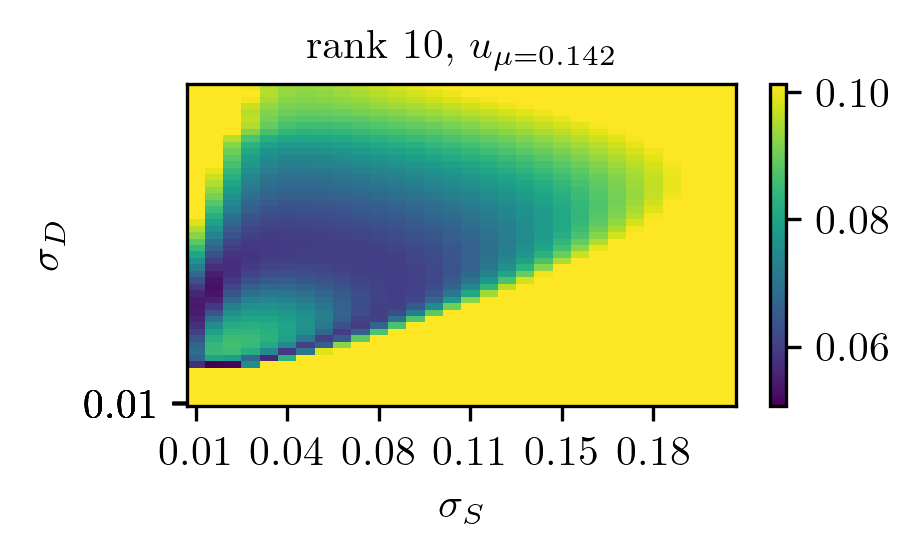

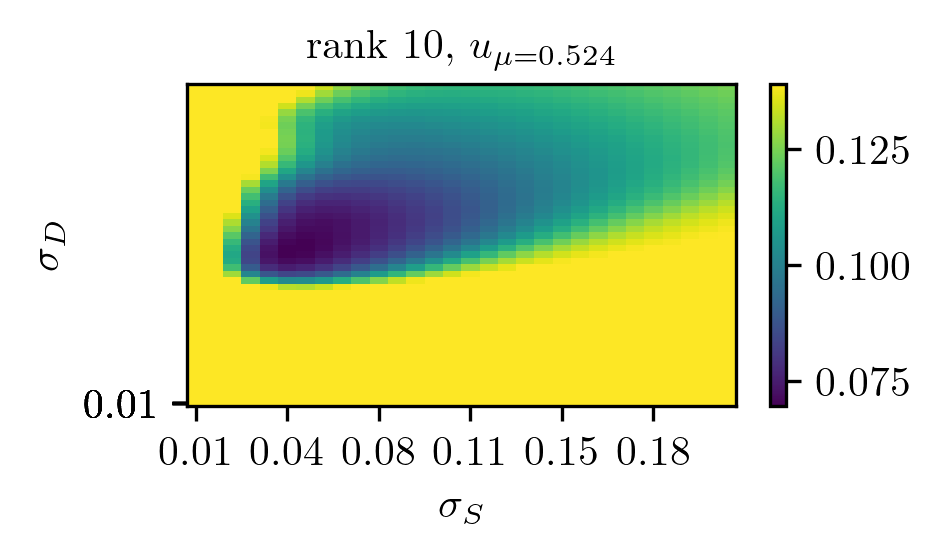

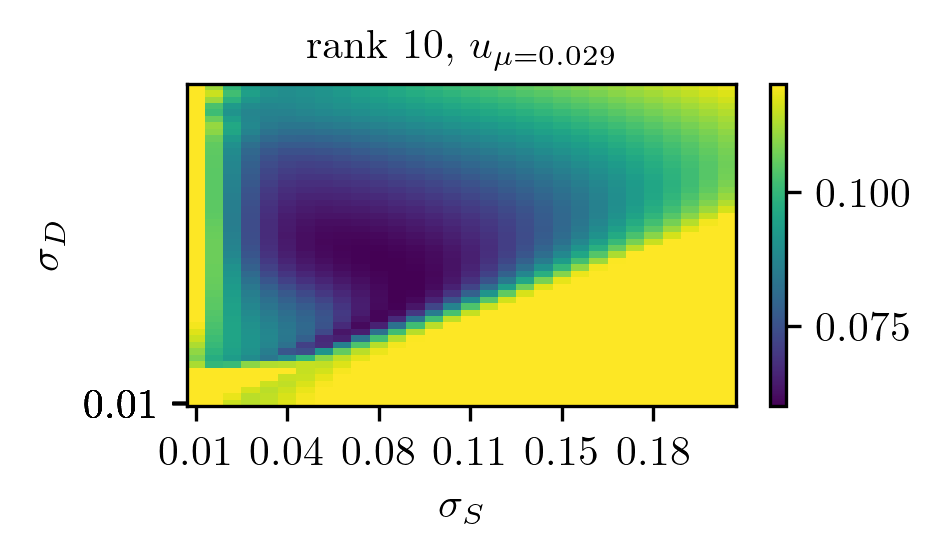

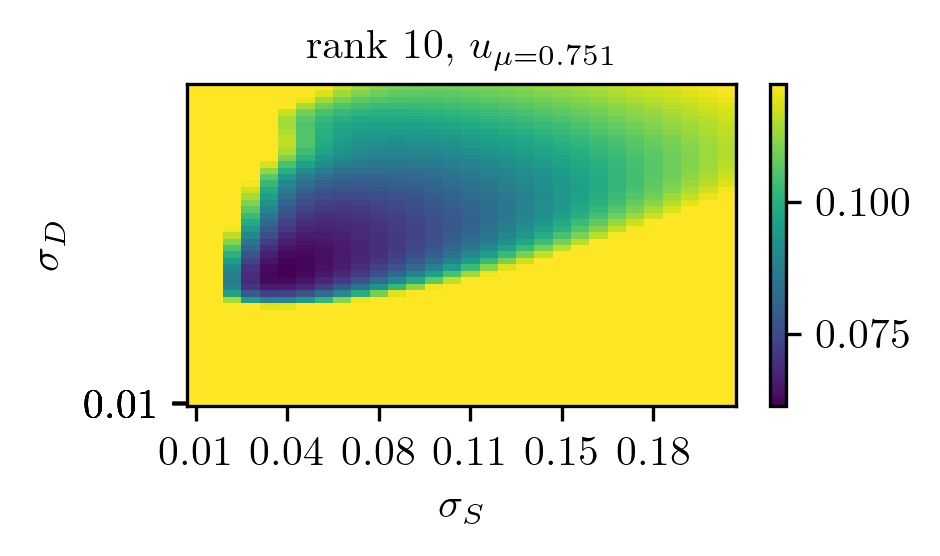

0.0025000000000000005 0.07500000000000001
[[0.77092681]
 [0.87495919]
 [0.98420059]
 [0.57616601]
 [0.78096172]
 [0.87815266]
 [0.41079037]
 [0.42615779]
 [0.93238653]
 [0.77420334]
 [0.71266697]
 [0.35646591]
 [0.63733865]
 [0.88004379]
 [0.45684711]
 [0.89308824]
 [0.13481578]
 [0.49564956]
 [0.7529567 ]
 [0.00712763]]
[[0.59157677]
 [0.05117507]
 [0.71856808]
 [0.87343417]
 [0.1872581 ]
 [0.2909454 ]
 [0.613858  ]
 [0.84335392]
 [0.95412294]
 [0.45661934]]
100, 0.06300000, 5.00000000, 0.11843781, 0.12626821, 0.06397173, -45.9871
100, 0.10433333, 5.00000000, 0.11843781, 0.13509389, 0.08179228, -30.9407
100, 0.02166667, 5.00000000, 0.11843781, 0.11413997, 0.12335143, 4.1487
100, 0.06300000, 8.33333333, 0.11843781, 0.12626821, 0.06960964, -41.2268
100, 0.06300000, 1.66666667, 0.11843781, 0.12626821, 0.08977811, -24.1981
100, 0.10433333, 8.33333333, 0.11843781, 0.13509389, 0.11555249, -2.4362
100, 0.02166667, 8.33333333, 0.11843781, 0.11413997, 0.11132189, -6.0082
100, 0.07677778, 5.000

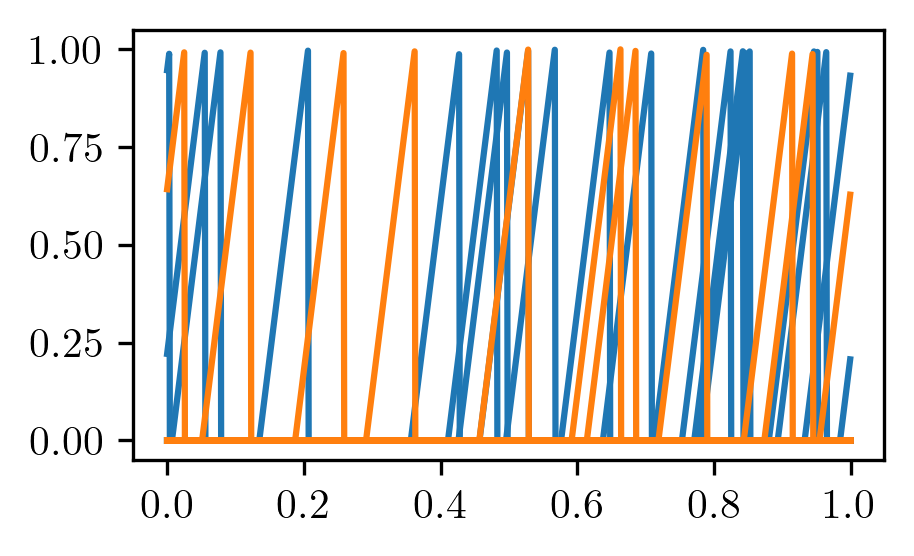

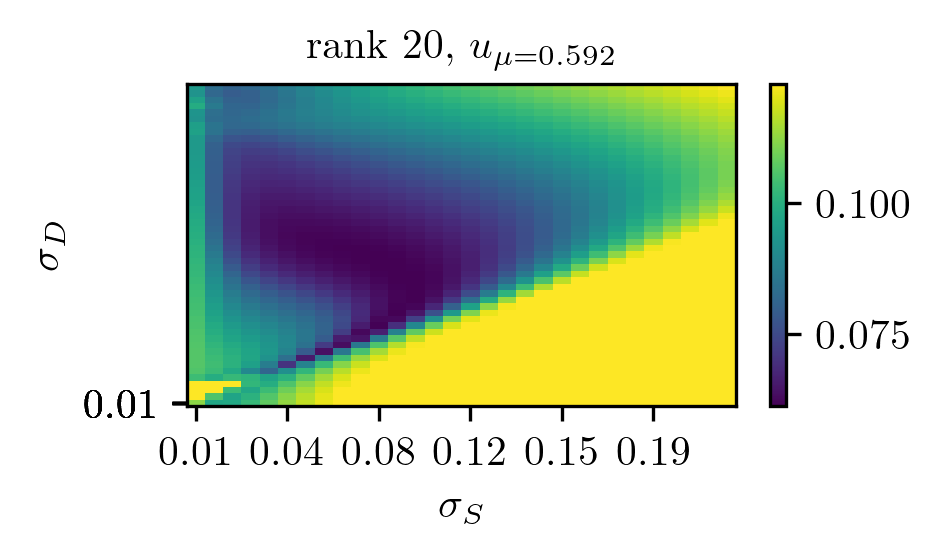

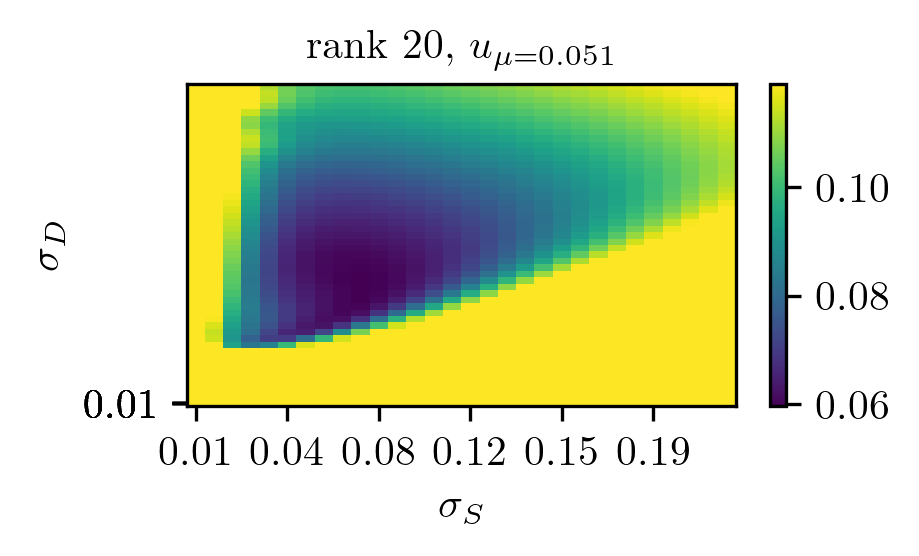

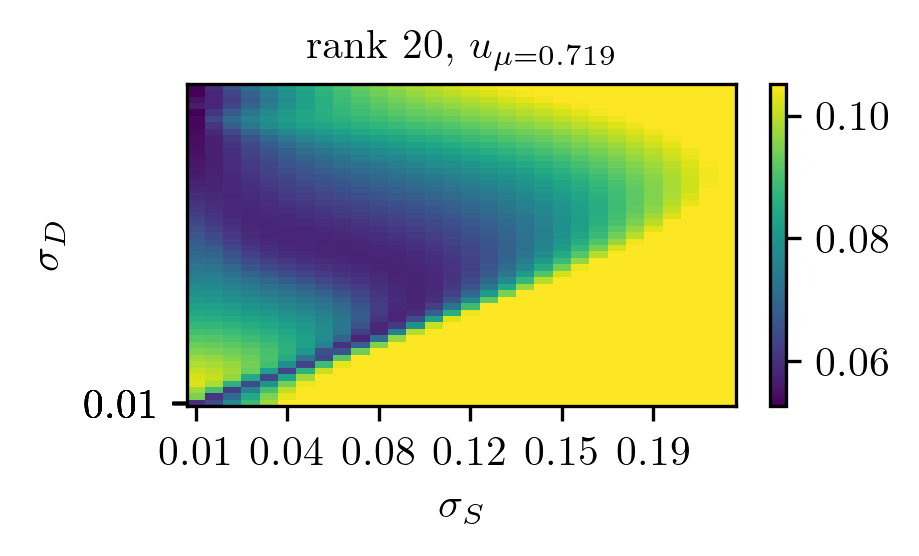

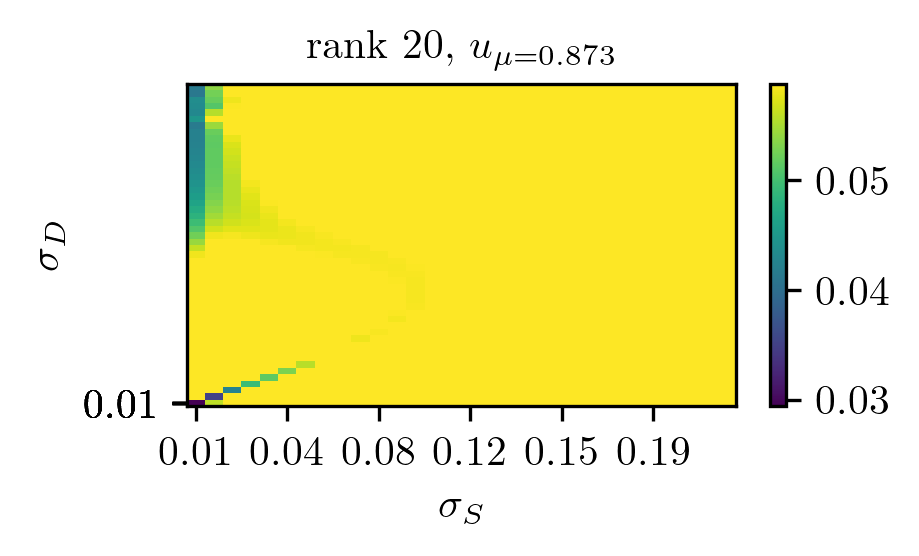

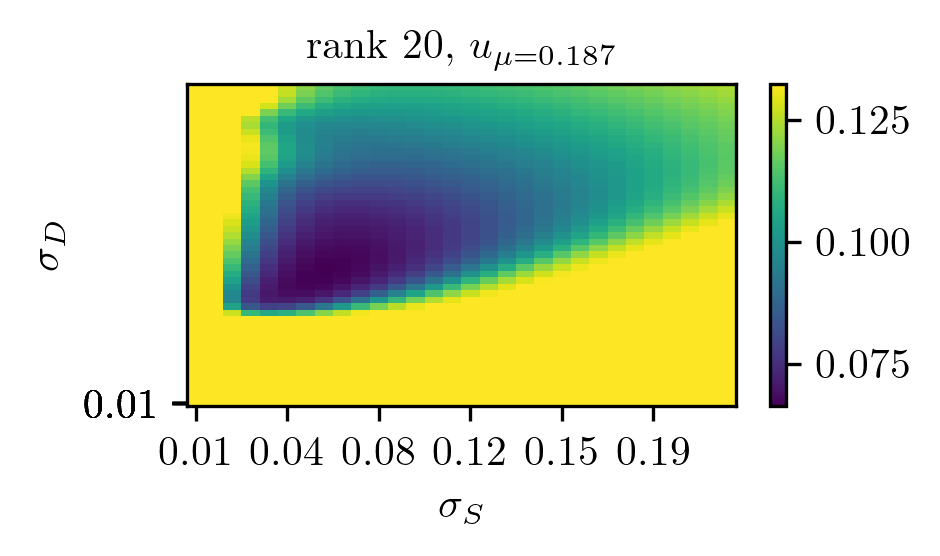

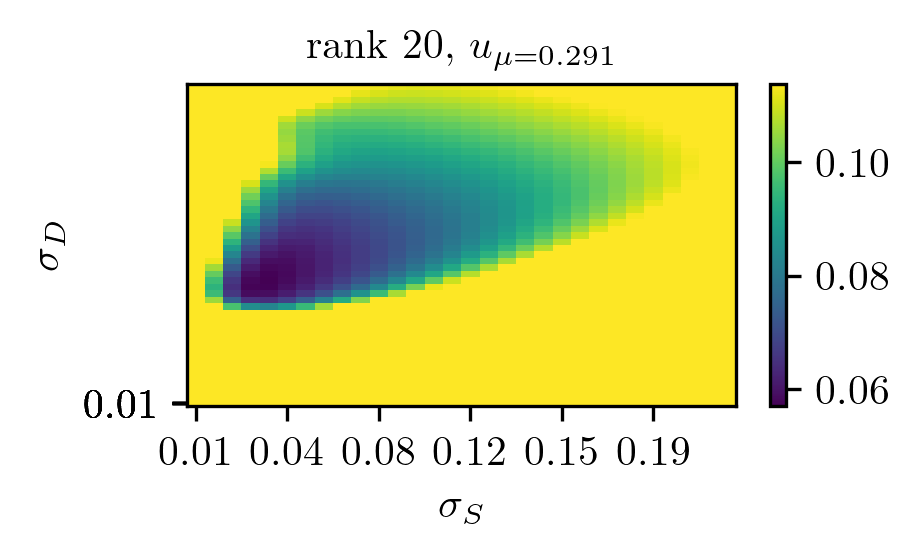

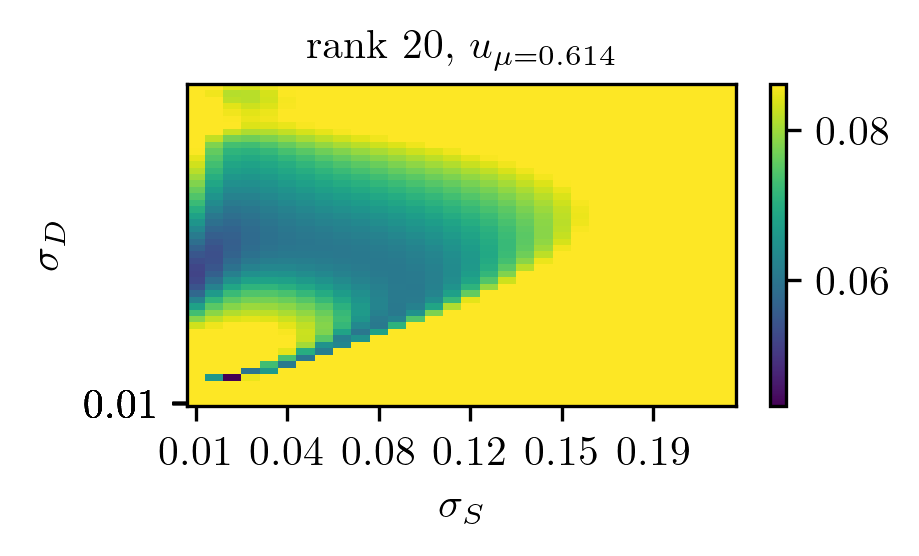

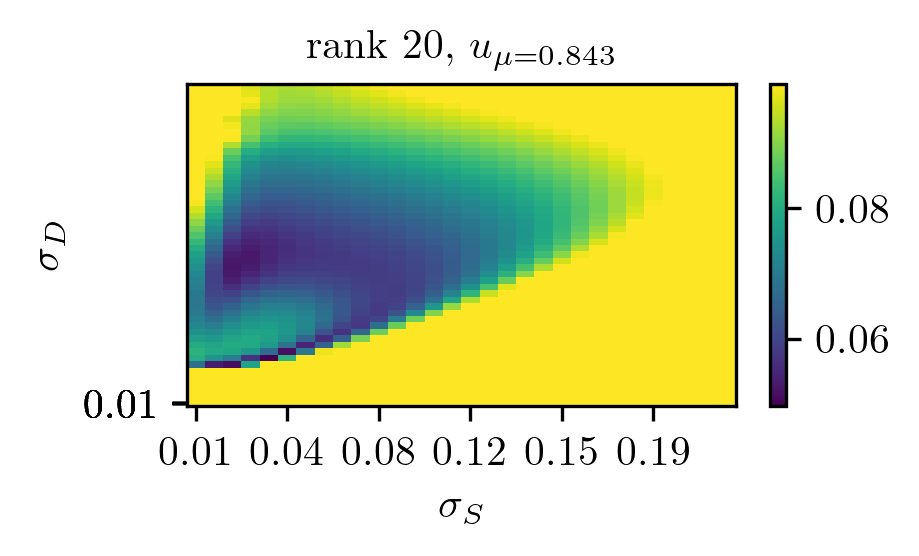

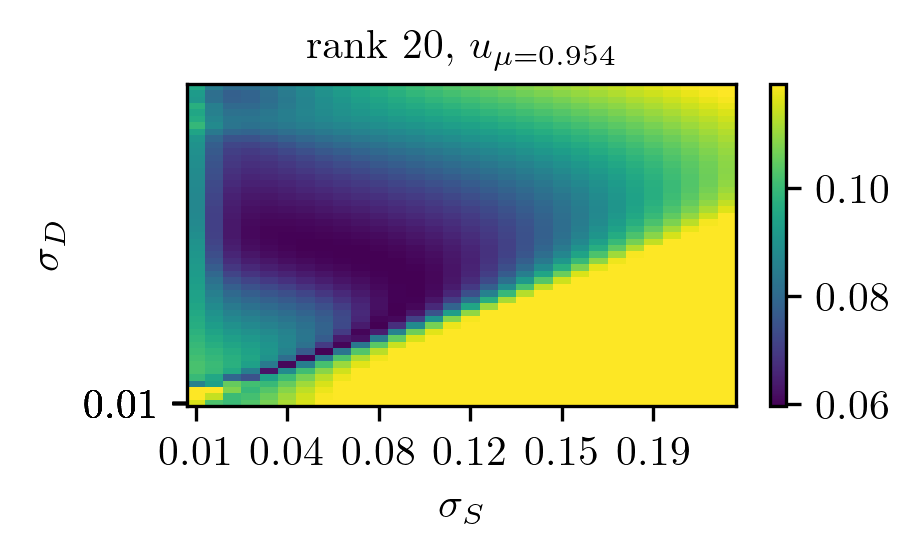

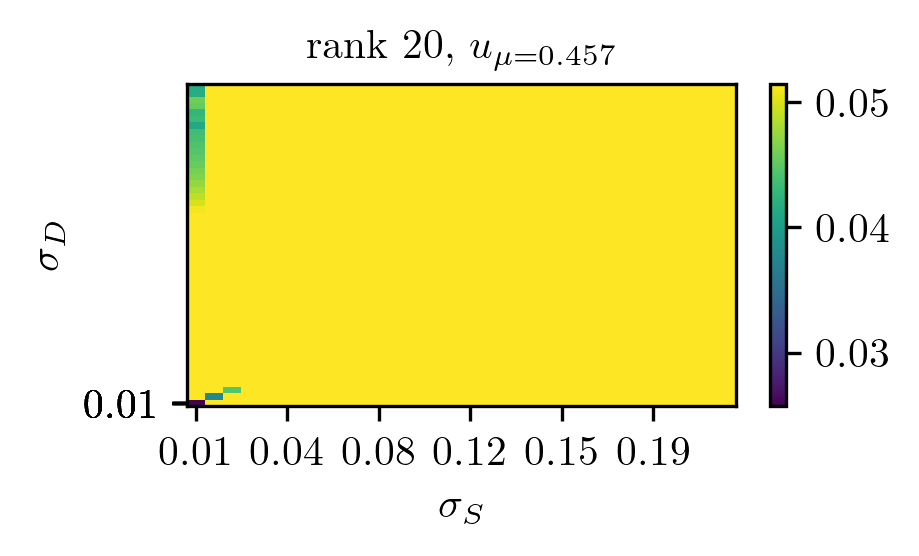

0.0016666666666666668 0.05
[[0.04888724]
 [0.29088464]
 [0.86803025]
 [0.84150063]
 [0.79073503]
 [0.54214246]
 [0.65694652]
 [0.18455042]
 [0.79027009]
 [0.11464659]
 [0.14480558]
 [0.05666589]
 [0.11552266]
 [0.41395263]
 [0.62844079]
 [0.6614234 ]
 [0.61288287]
 [0.18094428]
 [0.07027295]
 [0.03889198]
 [0.98586767]
 [0.19389528]
 [0.00544592]
 [0.96345977]
 [0.16319605]
 [0.7829271 ]
 [0.65322766]
 [0.54106693]
 [0.3673565 ]
 [0.03227147]]
[[0.31045962]
 [0.86711372]
 [0.92564746]
 [0.34537942]
 [0.17798843]
 [0.62300224]
 [0.22929453]
 [0.27244201]
 [0.92269275]
 [0.046862  ]]
100, 0.04216667, 5.00000000, 0.10633791, 0.11370594, 0.07843733, -26.2377
100, 0.06961111, 5.00000000, 0.10633791, 0.12546277, 0.06245940, -41.2633
100, 0.01472222, 5.00000000, 0.10633791, 0.10152249, 0.11926509, 12.1567
100, 0.04216667, 8.33333333, 0.10633791, 0.11370594, 0.06969137, -34.4623
100, 0.04216667, 1.66666667, 0.10633791, 0.11370594, 0.07563555, -28.8725
100, 0.06961111, 8.33333333, 0.10633791, 0

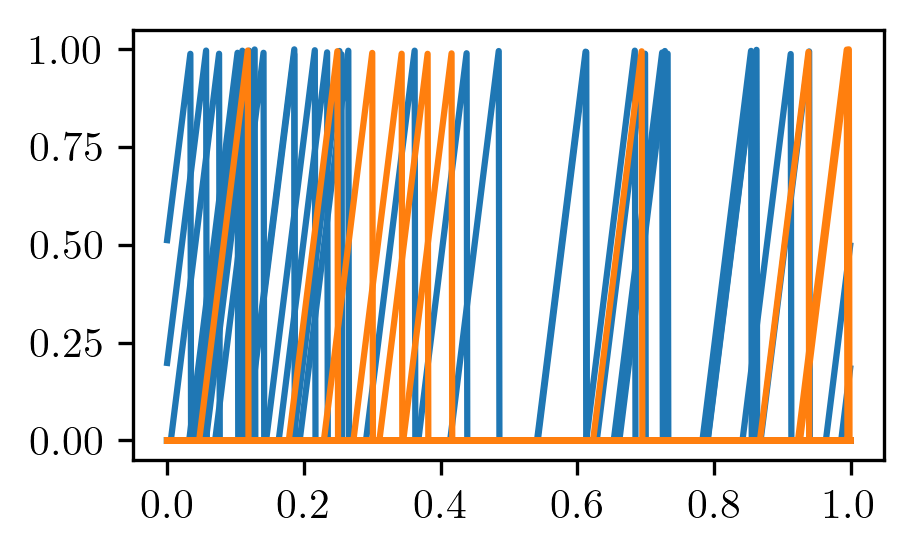

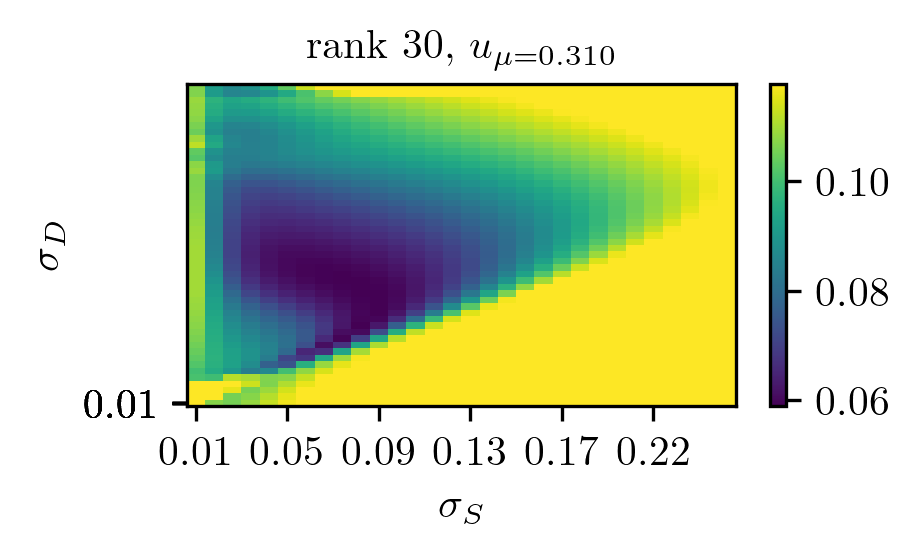

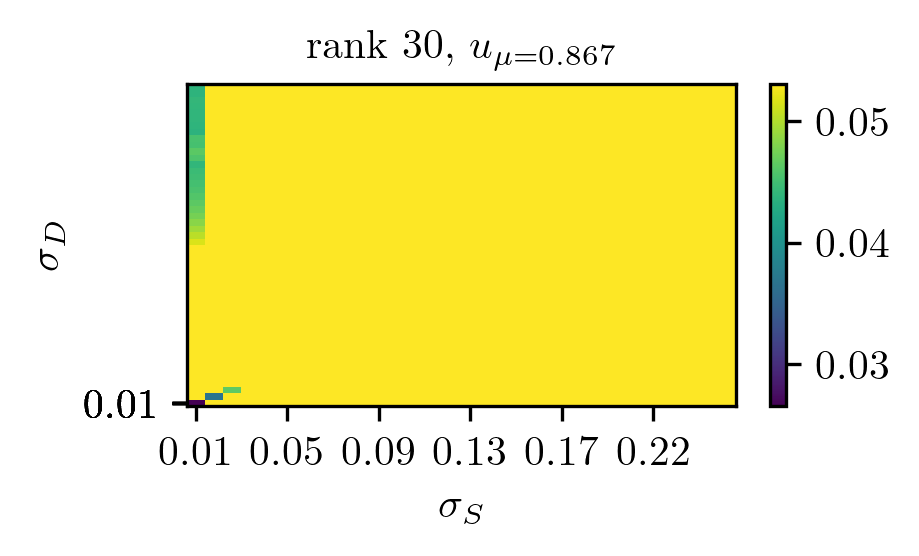

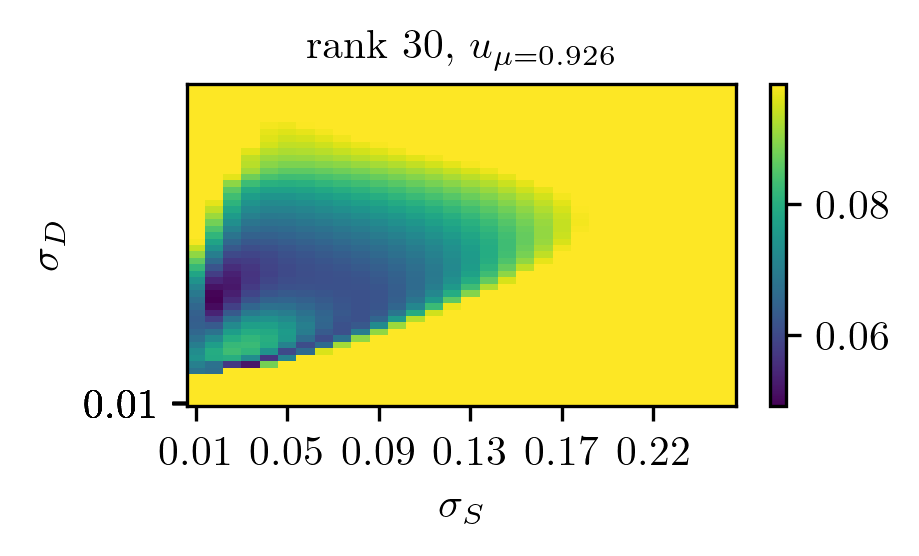

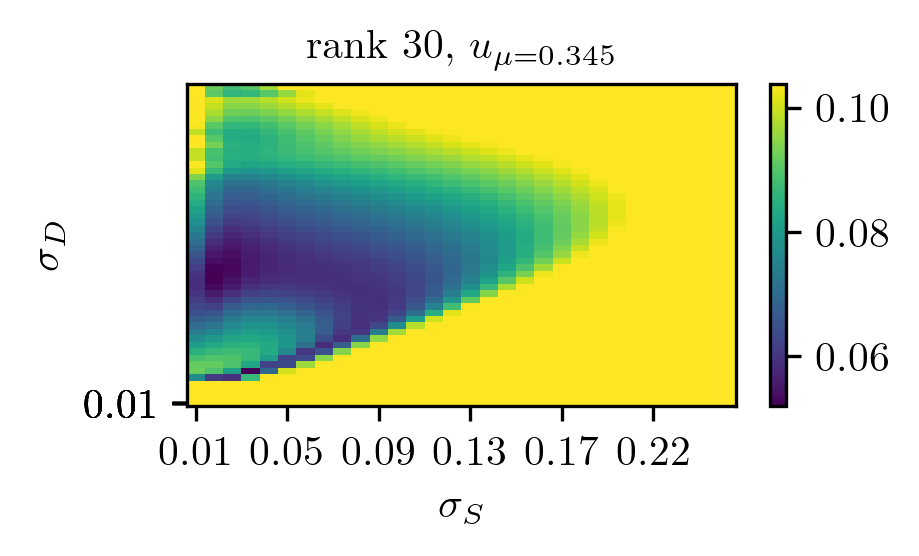

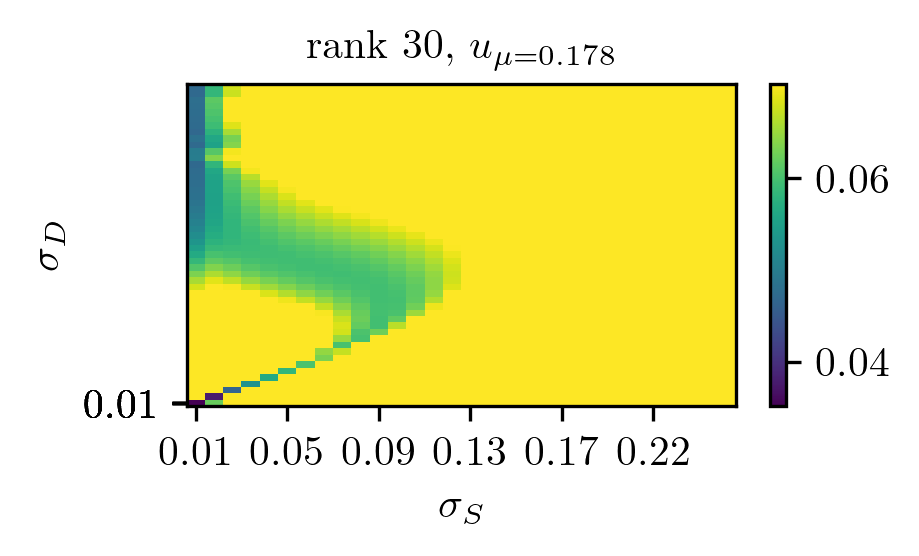

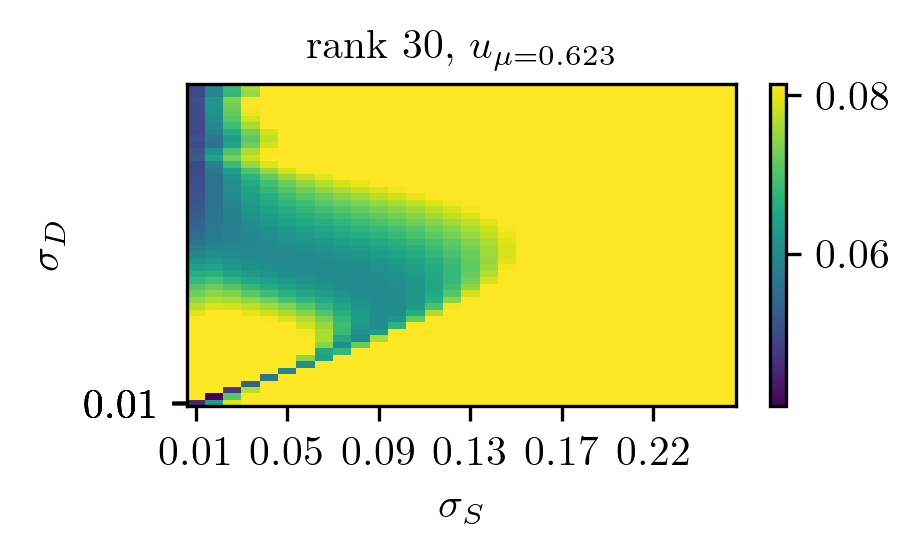

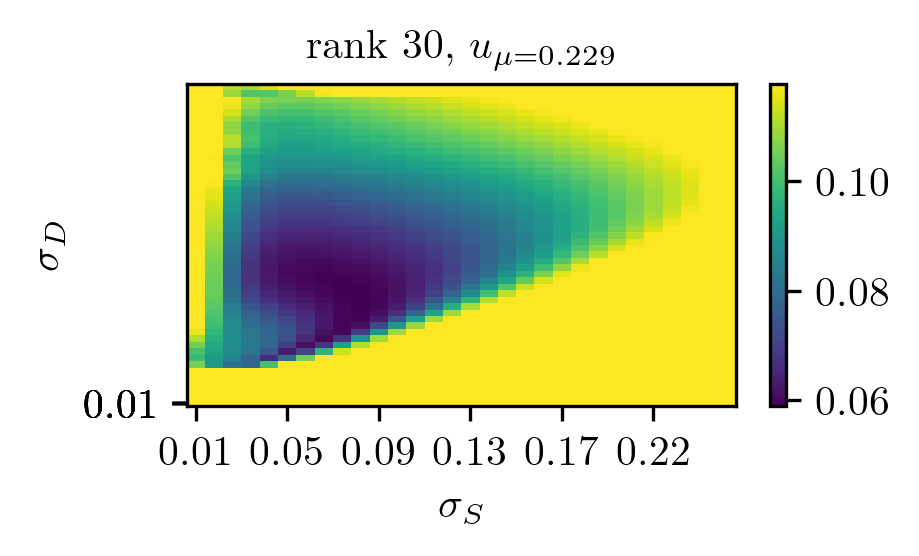

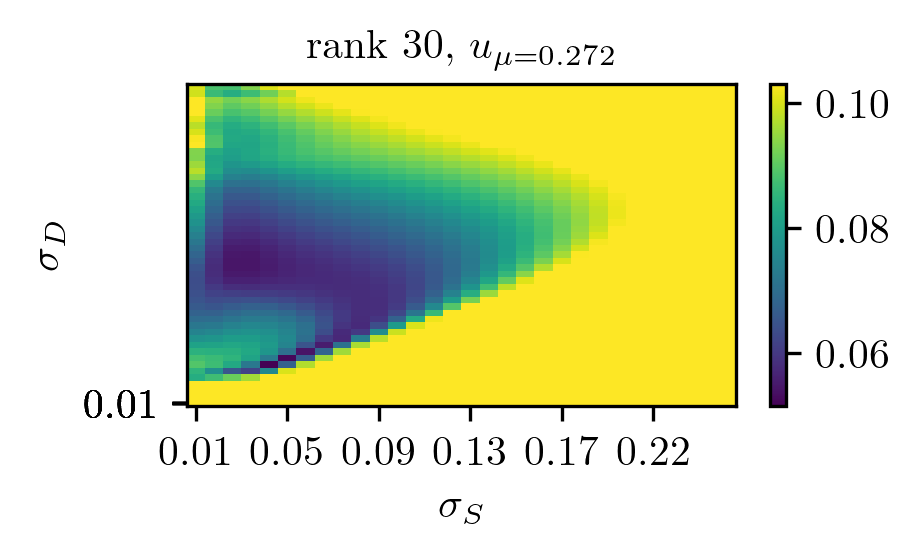

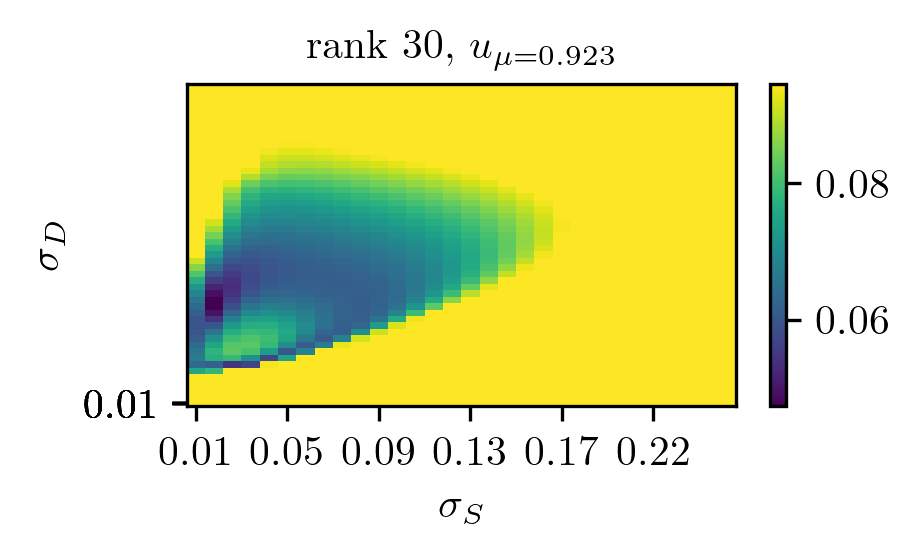

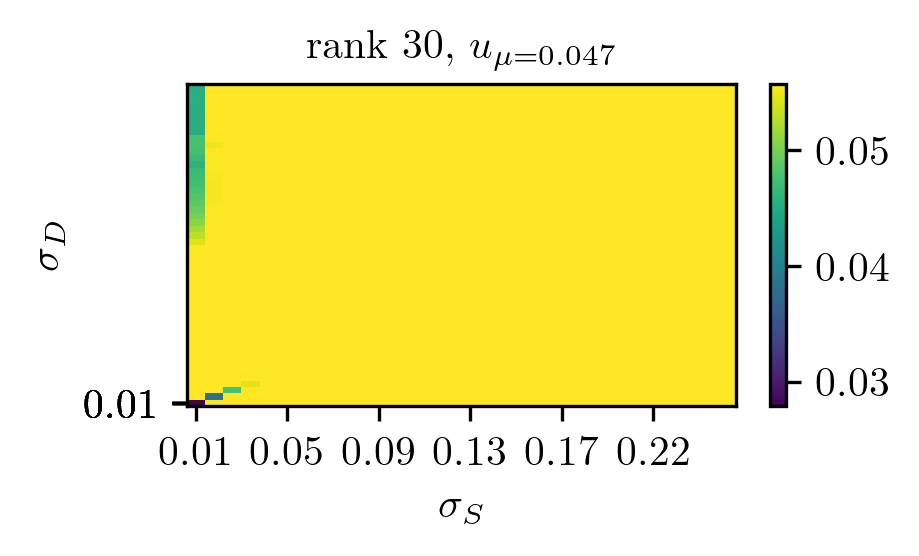

0.001 0.03
[[0.17035749]
 [0.16821213]
 [0.3298421 ]
 [0.98503153]
 [0.21172721]
 [0.12137795]
 [0.25465812]
 [0.88723655]
 [0.42953441]
 [0.06258411]
 [0.71333585]
 [0.13011588]
 [0.77125806]
 [0.79463314]
 [0.22044132]
 [0.98693744]
 [0.38421674]
 [0.30421665]
 [0.06493501]
 [0.12842963]
 [0.0678881 ]
 [0.79241976]
 [0.82803533]
 [0.93344924]
 [0.3853386 ]
 [0.70020775]
 [0.74542598]
 [0.87668063]
 [0.48283529]
 [0.16843224]
 [0.76636655]
 [0.22592144]
 [0.06110347]
 [0.29909671]
 [0.7178693 ]
 [0.34277222]
 [0.71702532]
 [0.20594413]
 [0.77438211]
 [0.28961058]
 [0.10308508]
 [0.51557067]
 [0.57740368]
 [0.69203251]
 [0.68780414]
 [0.81190978]
 [0.35331178]
 [0.62690594]
 [0.64232644]
 [0.58139238]]
[[0.47003241]
 [0.64035635]
 [0.12532908]
 [0.46187411]
 [0.39148478]
 [0.07975804]
 [0.60695121]
 [0.4414007 ]
 [0.97137924]
 [0.80111208]]
100, 0.02550000, 5.00000000, 0.08432390, 0.09075060, 0.09294601, 10.2250
100, 0.04183333, 5.00000000, 0.08432390, 0.10700988, 0.07722376, -8.4201
1

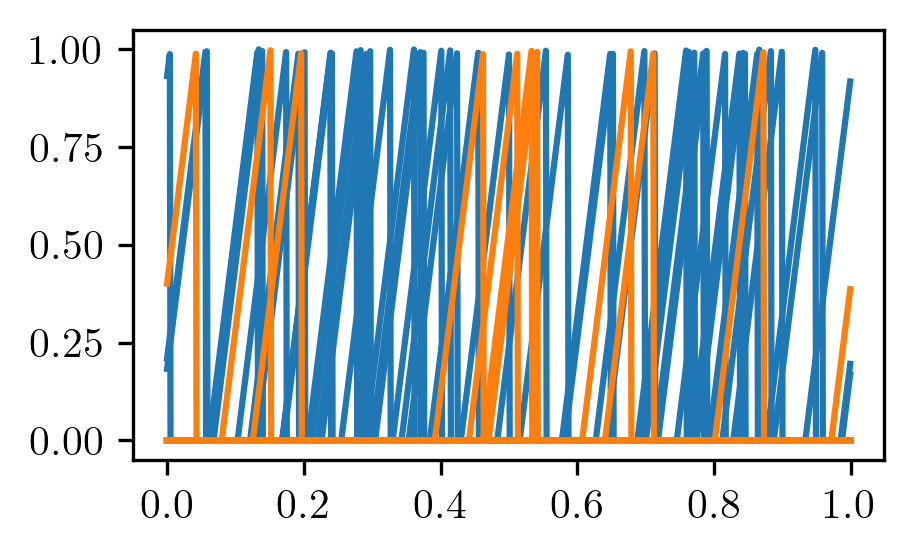

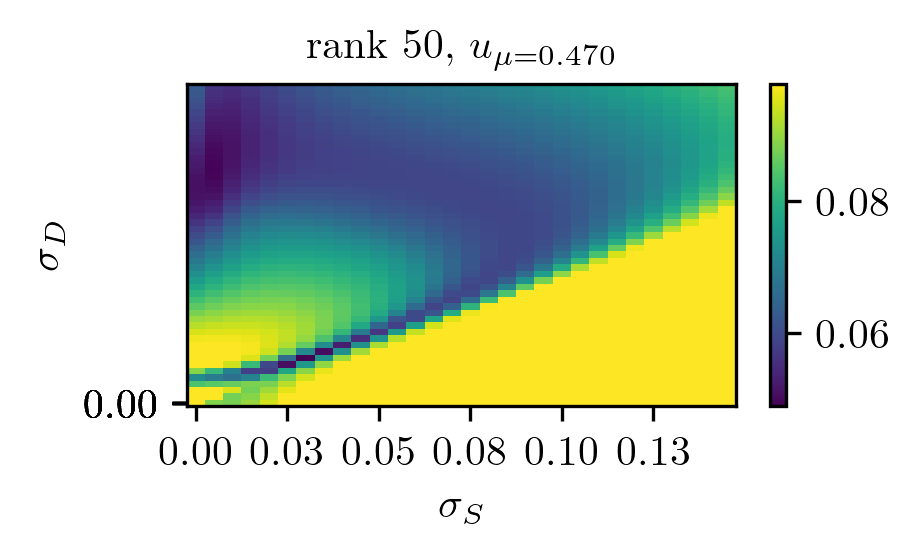

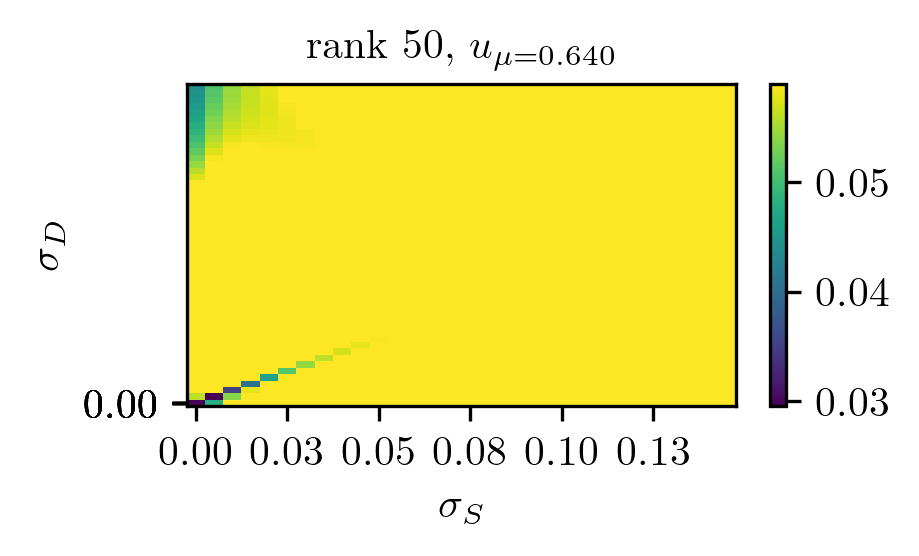

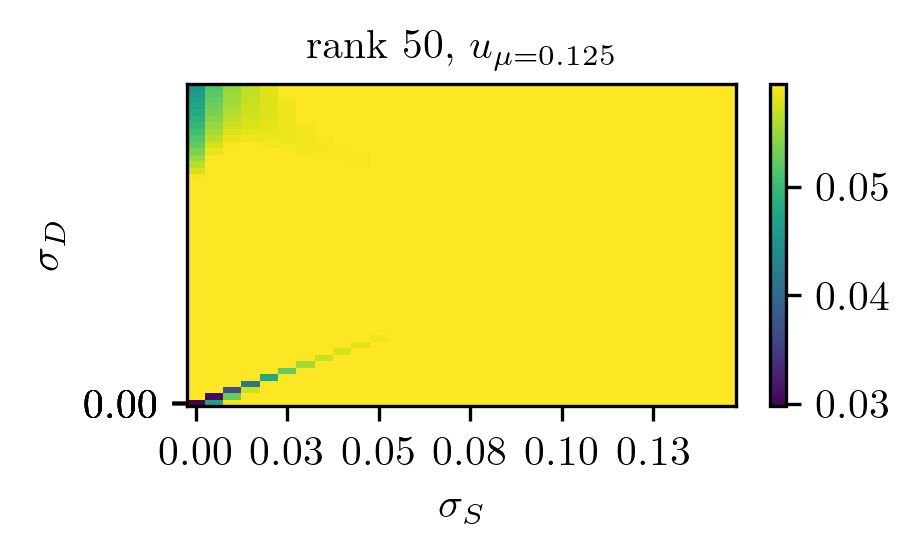

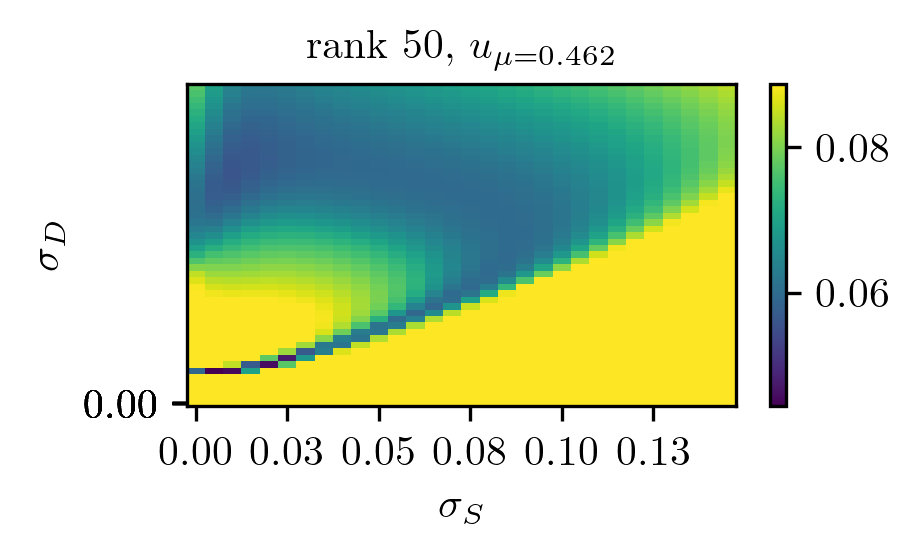

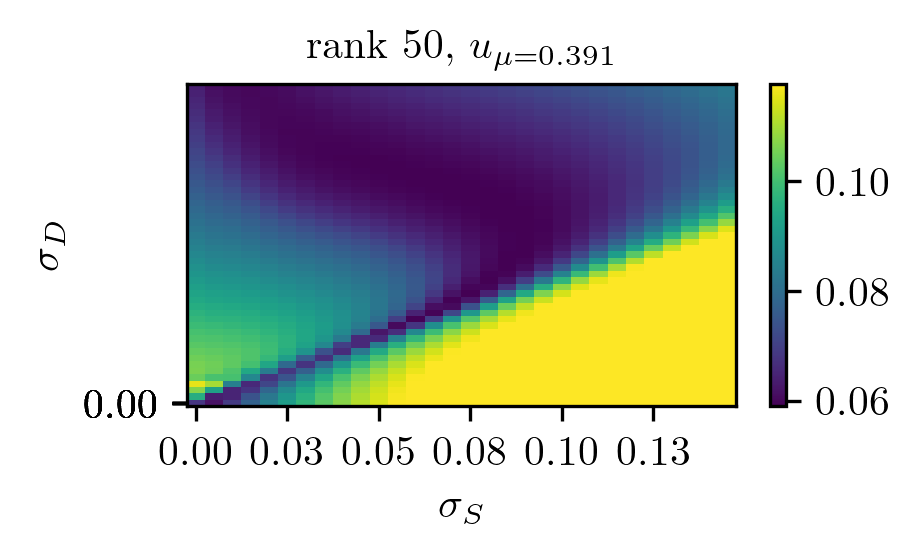

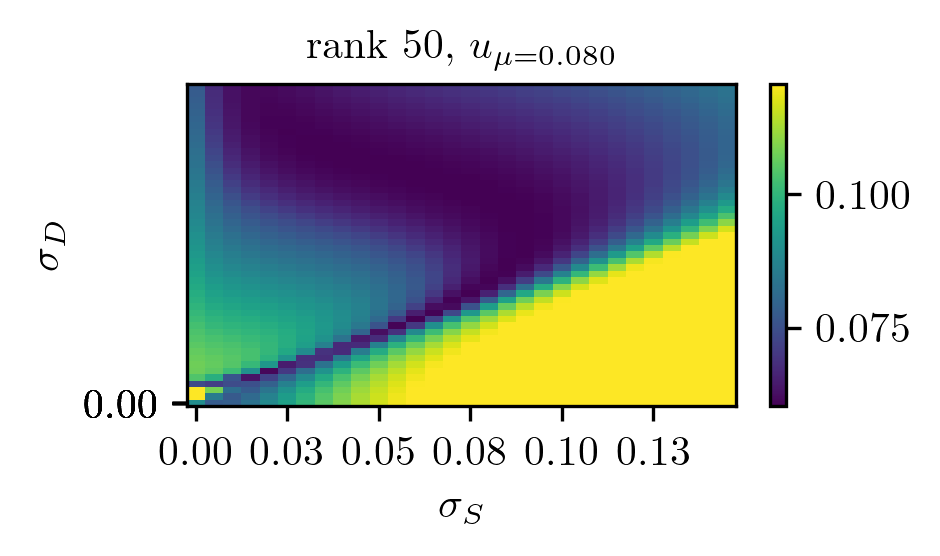

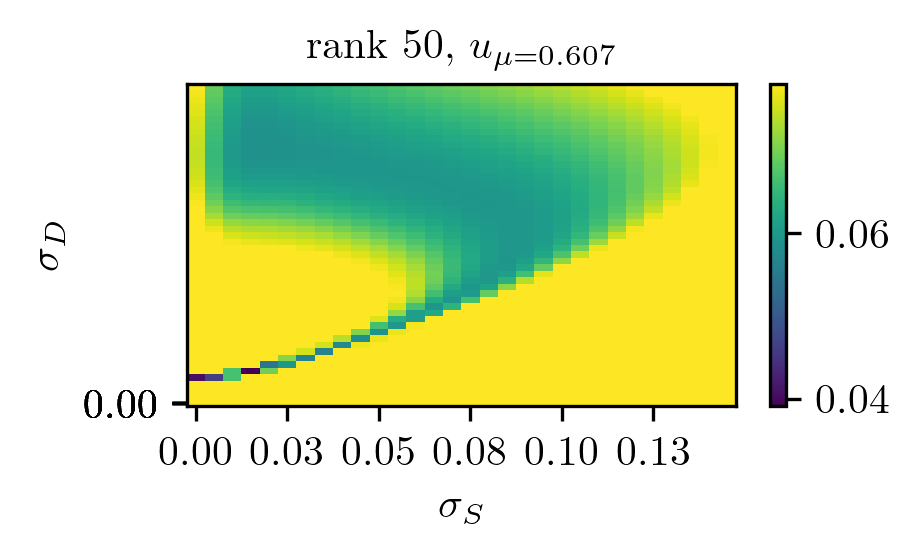

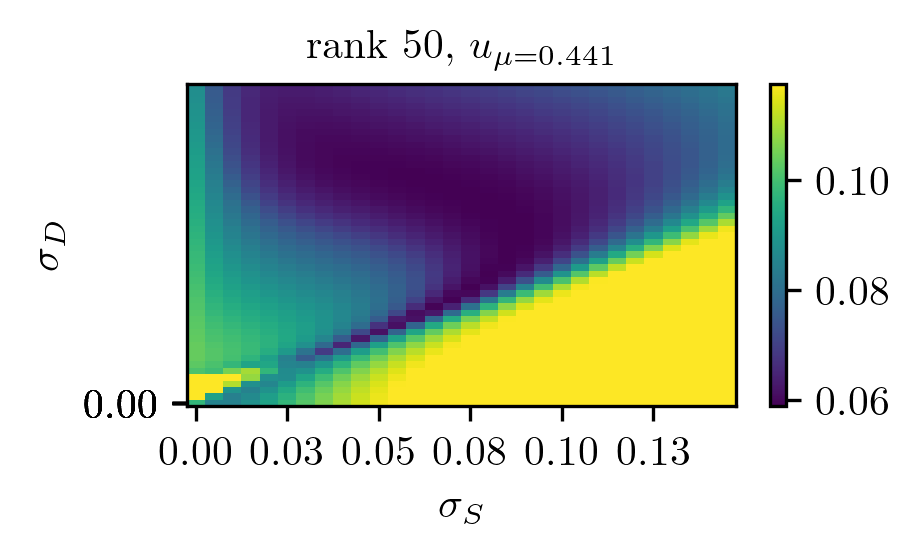

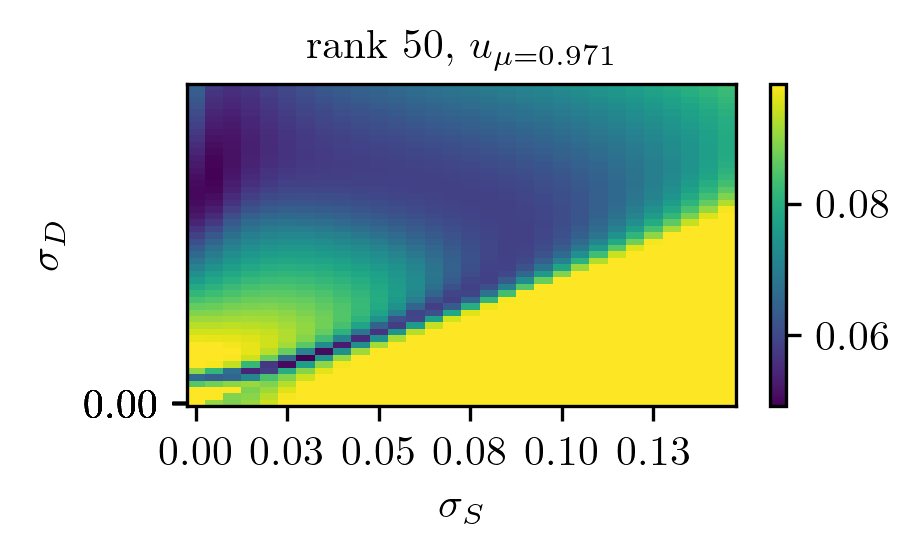

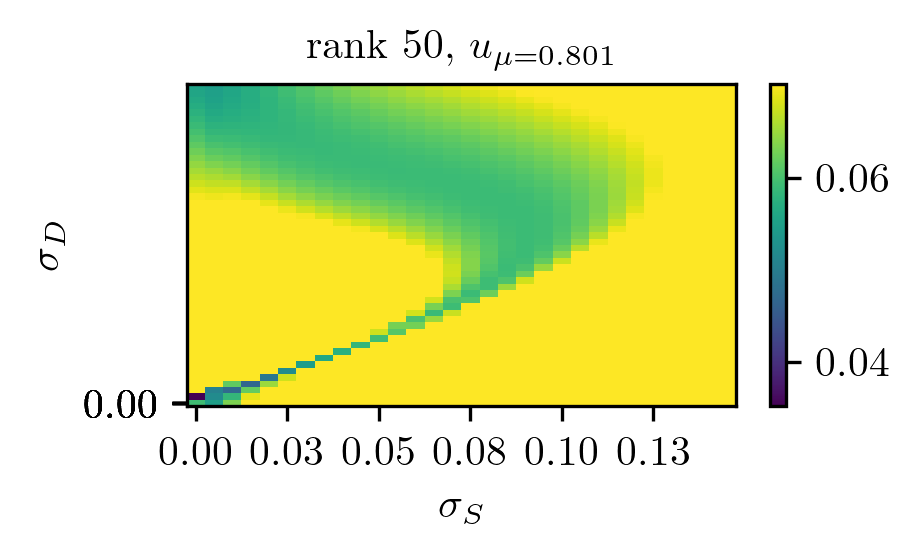

0.0005 0.015
[[0.15173079]
 [0.4900586 ]
 [0.34672087]
 [0.57240539]
 [0.72009109]
 [0.8272587 ]
 [0.9520735 ]
 [0.93684564]
 [0.59346263]
 [0.23577575]
 [0.49294943]
 [0.11244532]
 [0.93356061]
 [0.58390648]
 [0.71750371]
 [0.19736924]
 [0.50841996]
 [0.22102818]
 [0.34402941]
 [0.84293703]
 [0.02239375]
 [0.4547236 ]
 [0.69916246]
 [0.01944235]
 [0.64684623]
 [0.31278191]
 [0.45006954]
 [0.61710387]
 [0.75674842]
 [0.30557667]
 [0.63614713]
 [0.41946784]
 [0.85936718]
 [0.15932445]
 [0.30995315]
 [0.36331512]
 [0.64713053]
 [0.44892519]
 [0.61489785]
 [0.0161287 ]
 [0.27524879]
 [0.2317285 ]
 [0.652182  ]
 [0.55408595]
 [0.73139726]
 [0.6247873 ]
 [0.75624075]
 [0.79997038]
 [0.89409645]
 [0.08338394]
 [0.4422648 ]
 [0.37184768]
 [0.98234481]
 [0.08095288]
 [0.518048  ]
 [0.37099005]
 [0.2553671 ]
 [0.70539565]
 [0.2177293 ]
 [0.52755764]
 [0.20980791]
 [0.07371923]
 [0.82958898]
 [0.8348039 ]
 [0.30334786]
 [0.15931137]
 [0.8821499 ]
 [0.69300926]
 [0.91750551]
 [0.72631249]
 [0.301

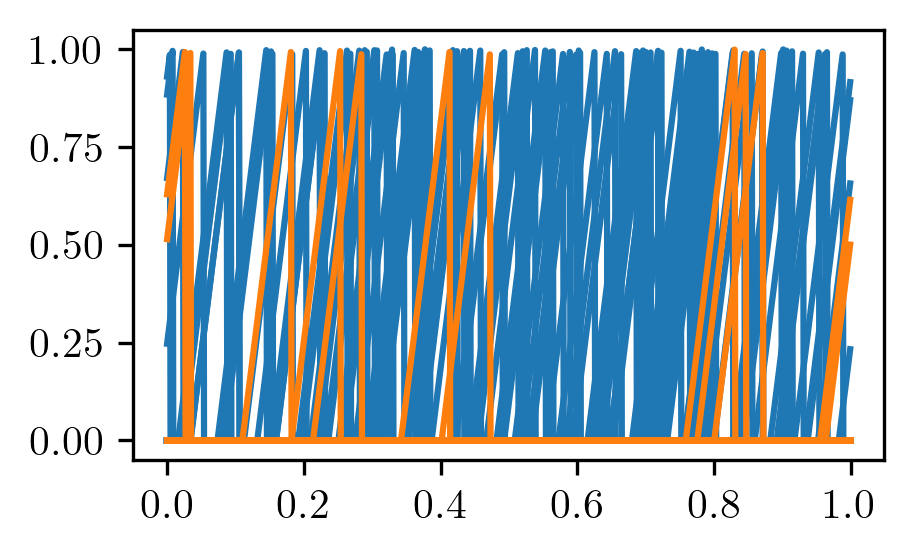

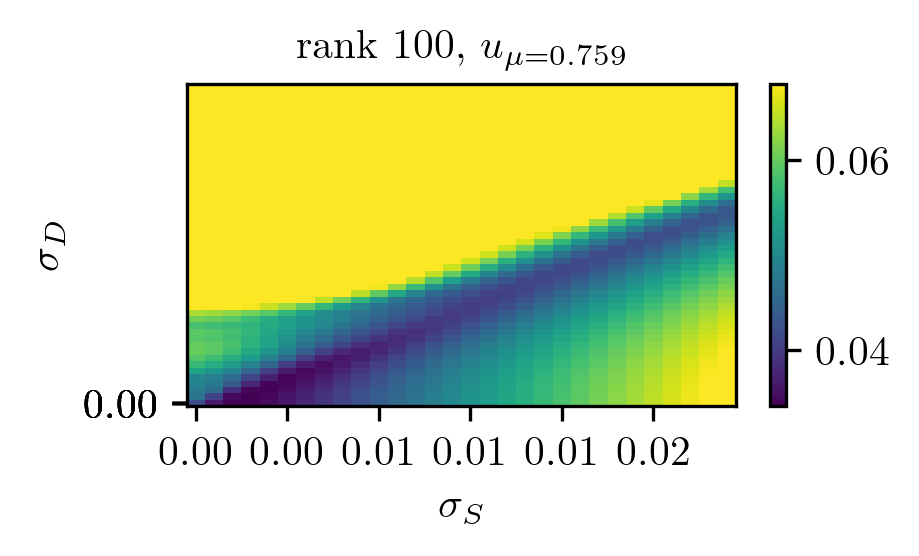

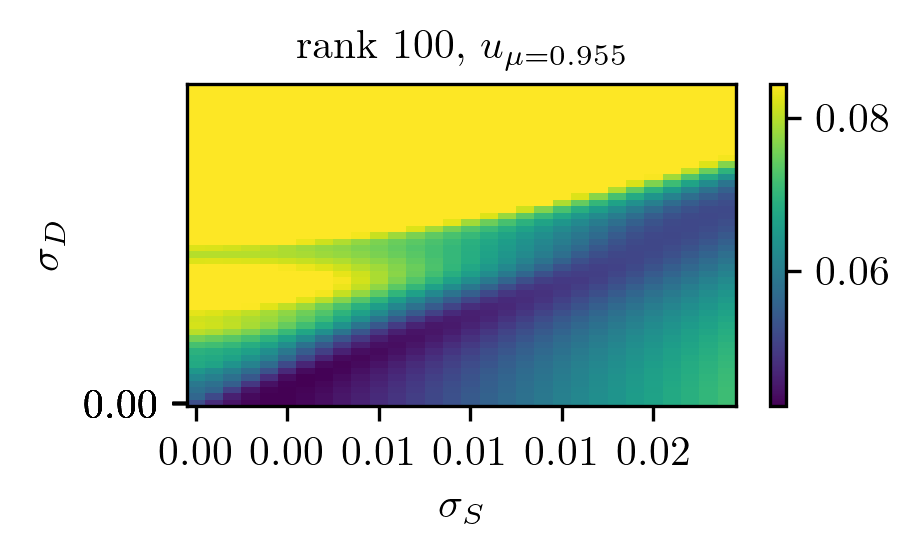

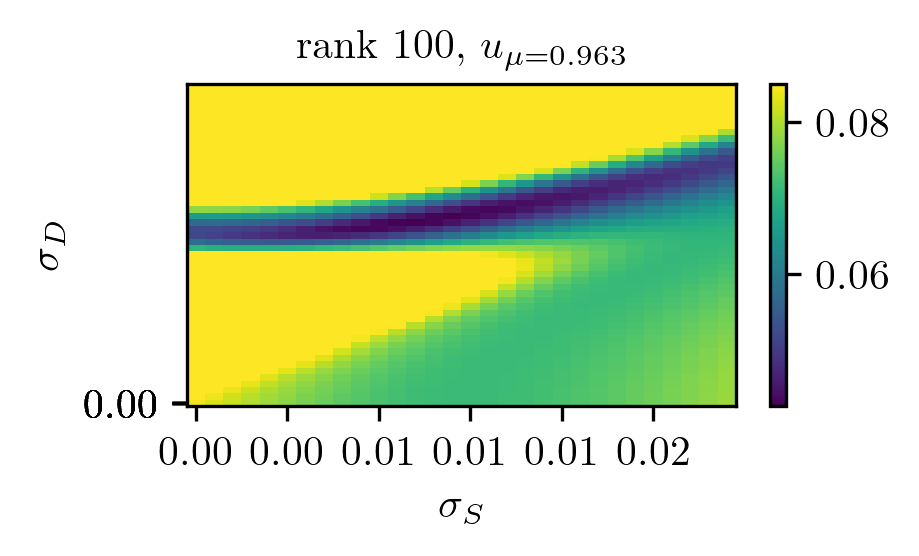

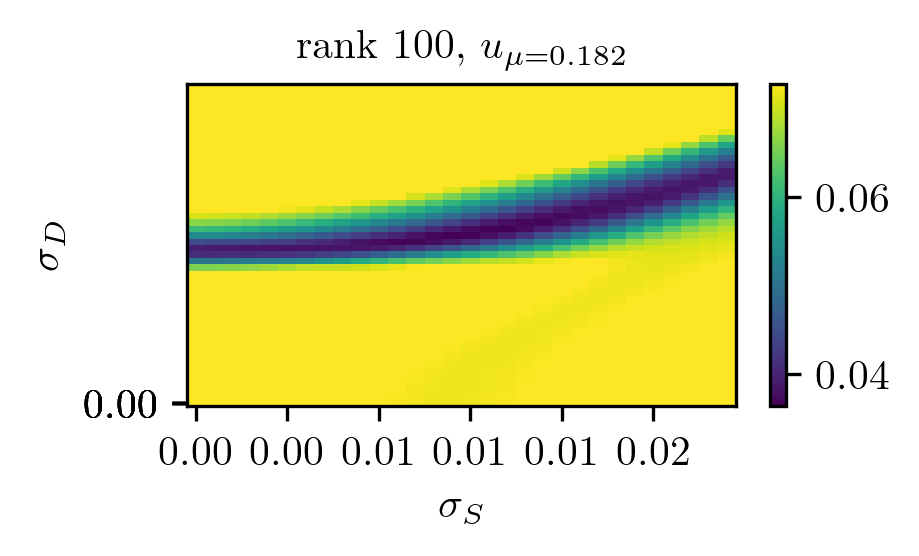

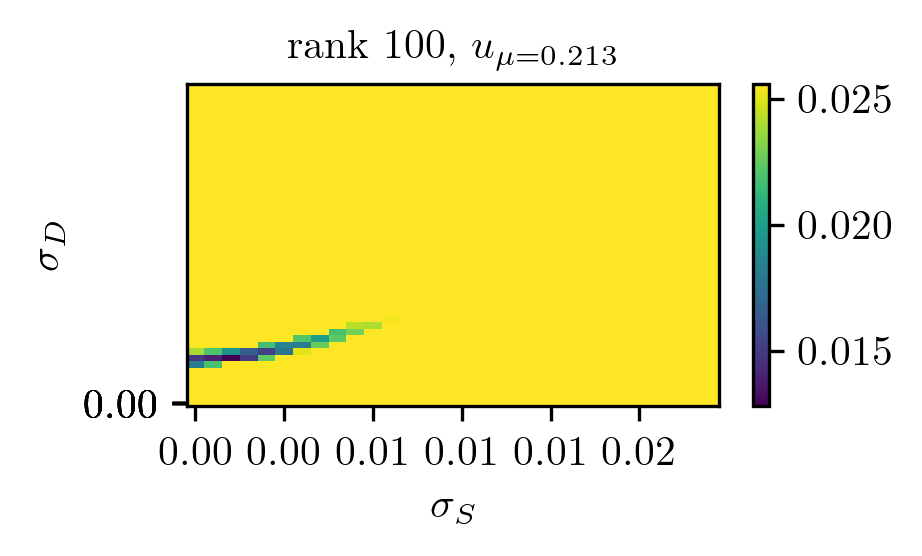

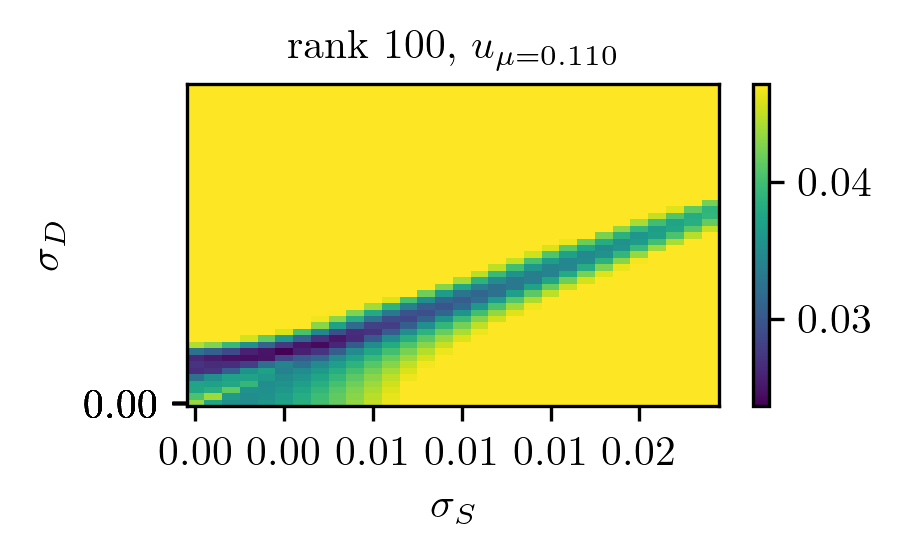

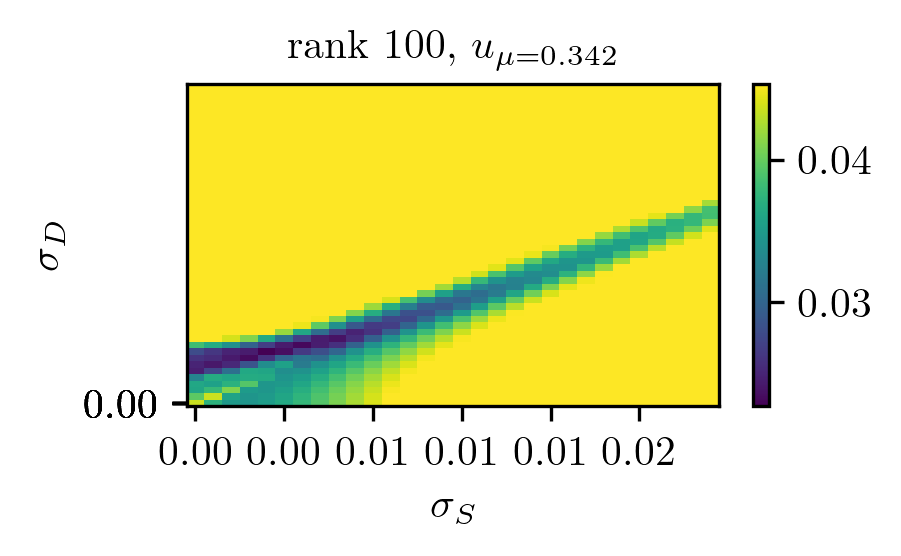

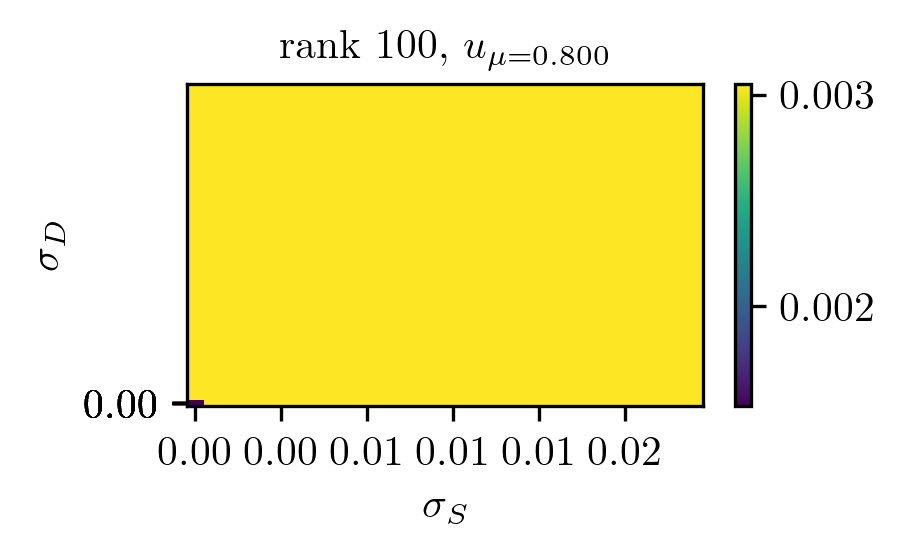

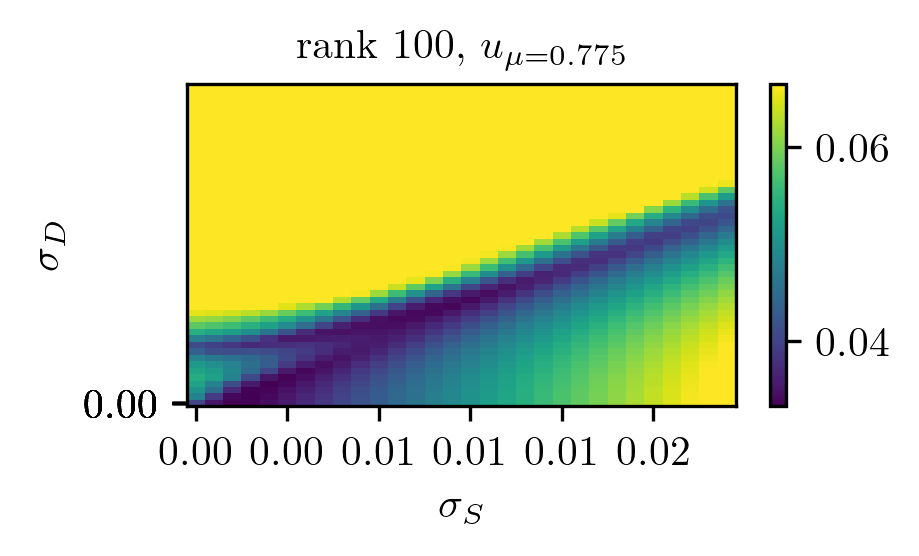

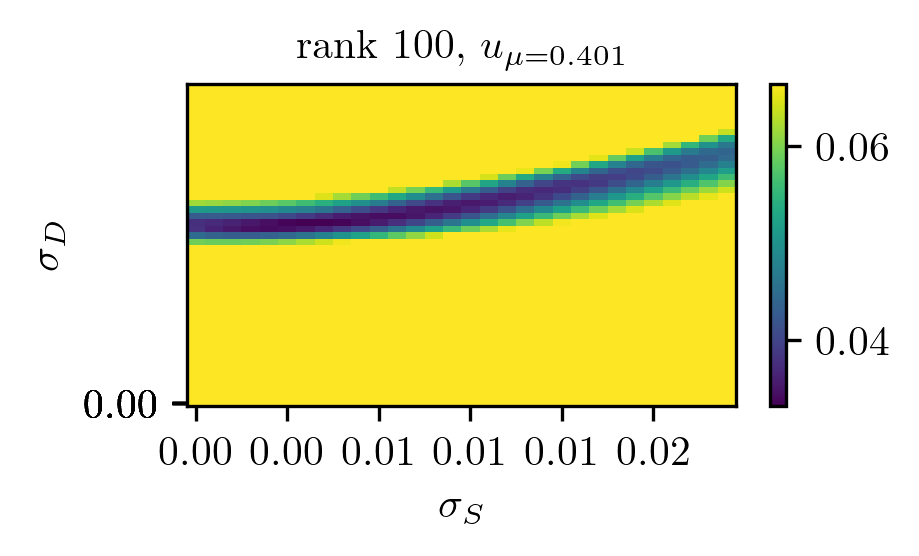

In [6]:
nsD = 50
nsS = 30
sigma_S = np.empty((5, 10, nsS, nsD))
sigma_D = np.empty((5, 10, nsS, nsD))
ranks = np.empty((5, 10, nsS, nsD))
mus = np.empty((5, 10, nsS, nsD))
errors = np.empty((5, 10, nsS, nsD))/0
mu_train_rankwise = [None, None, None, None, None]
mu_test_rankwise = [None, None, None, None, None]
X_train_rankwise = [None, None, None, None, None]
X_test_rankwise = [None, None, None, None, None]

for i, rank in enumerate([10, 20, 30, 50, 100]):
    case["rank"] = rank
    case["n_train"] = rank
    case["n_test"] = 10
    sigma_opt = 1 / (rank * 2)

    
    print(sigma_opt*0.1, sigma_opt*3)
    # TODO: optimize and 
    if RAND:
        mu_min, mu_max = np.array([0]), np.array([1])
        mu_train = np.atleast_2d(np.random.rand(case["n_train"],)[:, None] * (mu_max - mu_min) + mu_min)
        mu_min, mu_max = np.min(mu_train), np.max(mu_train)
        mu_test = np.atleast_2d(np.random.rand(case["n_test"],)[:, None] * (mu_max - mu_min) + mu_min)
    else:
        mu_min, mu_max = np.array([0]), np.array([1])
        mu_train = np.linspace(mu_min, mu_max, case["n_train"], endpoint=False)
        mu_min, mu_max = mu_train[1], mu_train[2]
        mu_test = np.linspace(mu_min, mu_max, case["n_test"], endpoint=False)
    print(mu_train)
    print(mu_test)
    del case["n_train"]
    del case["n_test"]
    case["sigmaD"] = "calc_based_on_distance"
    case["mu_train"], case["mu_test"] = mu_train, mu_test
    mu_train_rankwise[i], mu_test_rankwise[i] = mu_train, mu_test

    parameters = optimize_hyperparameters(case)
    print(parameters)
    
    sigma_opt = parameters[0]
    sSs = np.linspace(sigma_opt*0.1, sigma_opt*3, nsS)
    sDs = np.linspace(sigma_opt*0.1, sigma_opt*5, nsD)
    xx, yy = np.meshgrid(sSs, sDs, indexing="ij")

    for r, sgm_S in enumerate(sSs):
        case["sigma"] = sgm_S
        X_train, X_train_s = get_data_rw(mu_train, **case)
        X_test, X_test_s = get_data_rw(mu_test, **case)
        #X_train_rankwise[i], X_test_rankwise[i] = X_train, X_test  # dont change with sigma
        # mu_train, X_train, X_train_s = make_data(np.array([0]), np.array([1]), n_samples=case["n_train"], **case)
        # mu_min, mu_max = (np.min(mu_train), np.max(mu_train)) if RAND else (mu_train[1], mu_train[2])
        # mu_test, X_test, X_test_s = make_data(mu_min, mu_max, n_samples=case["n_test"], **case)
    
        my_sROM = train_ROM_rw(mu_train, X_train_s)
    
        for j, mu in enumerate(mu_test):
            for s, sgm_D in enumerate(sDs):
                #if (r-7<s) and (s<r+7):
                    case["sigmaD"] = [sgm_D]
                    
                    X_test_sROM, X_test_sROMs = get_predictions(my_sROM, np.array([mu]), **case)
                    e = L2_error_rw(X_test_sROMs[0], X_test[j], axis=0)
    
                    sigma_S[i, j, r, s] = sgm_S
                    sigma_D[i, j, r, s] = sgm_D
                    ranks[i, j, r, s] = rank
                    mus[i, j, r, s] = mu[0]
                    errors[i, j, r, s] = e
    for m in range(len(X_train)):
        plt.plot(case["x"], X_train[m], "C0-")
        print(m, mu_train[m], np.min(X_train[m]))
    for n in range(len(X_test)):
        print(n, mu_test[n], np.min( X_test[n]))
        plt.plot(case["x"], X_test[n], "C1-")
    plt.show()
    for j, mu in enumerate(mu_test):
        #plt.imshow(errors[i, j])
        fig, ax = plt.subplots()
        mesh = ax.pcolormesh(sigma_S[i, j], sigma_D[i, j], errors[i, j], shading=None, cmap='viridis', vmin=np.min(errors[i, j]), vmax=np.min(errors[i, j])*2)
        ax.set_xticks(sigma_S[i, j, ::5, 0])
        ax.set_yticks(sigma_D[i, j, ::5, 0])
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax.set_xlabel(r"$\sigma_S$")
        ax.set_ylabel(r"$\sigma_D$")
        
        plt.title("rank "+str(rank)+r", $u_{\mu"+"={:.3f}".format(mu[0])+r"}$")
        cbar = plt.colorbar(mesh, ax=ax)
        plt.show()


0 [0.00570483] 0.0
1 [0.60473328] 0.0
2 [0.29729287] 0.0
3 [0.29430628] 0.0
4 [0.26270413] 0.0
5 [0.33399959] 0.0
6 [0.09749581] 0.0
7 [0.24735489] 0.0
8 [0.18215844] 0.0
9 [0.82480859] 0.0
0 [0.05477522] 0.0
1 [0.81339809] 0.0
2 [0.2186094] 0.0
3 [0.63800296] 0.0
4 [0.70523244] 0.0
5 [0.15122565] 0.0
6 [0.14194749] 0.0
7 [0.52423038] 0.0
8 [0.02913778] 0.0
9 [0.75110444] 0.0
0 0


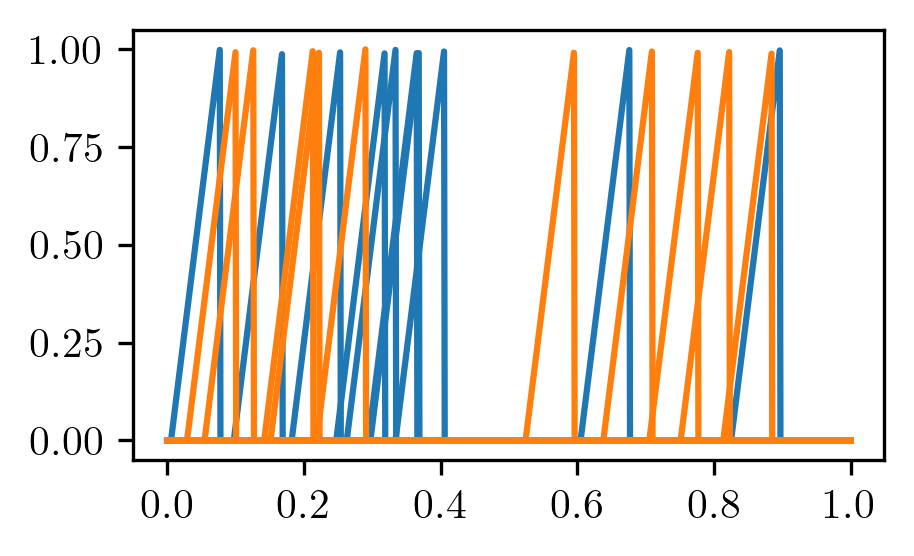

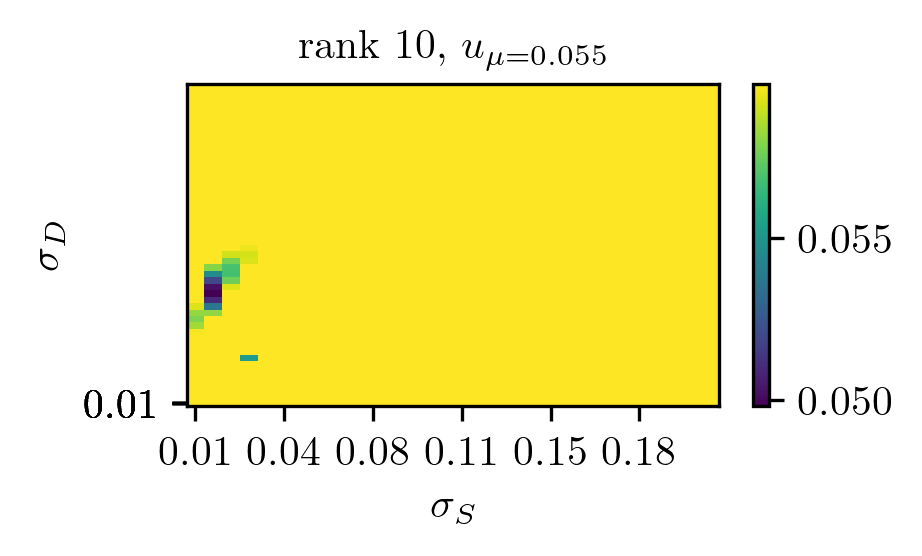

0 1


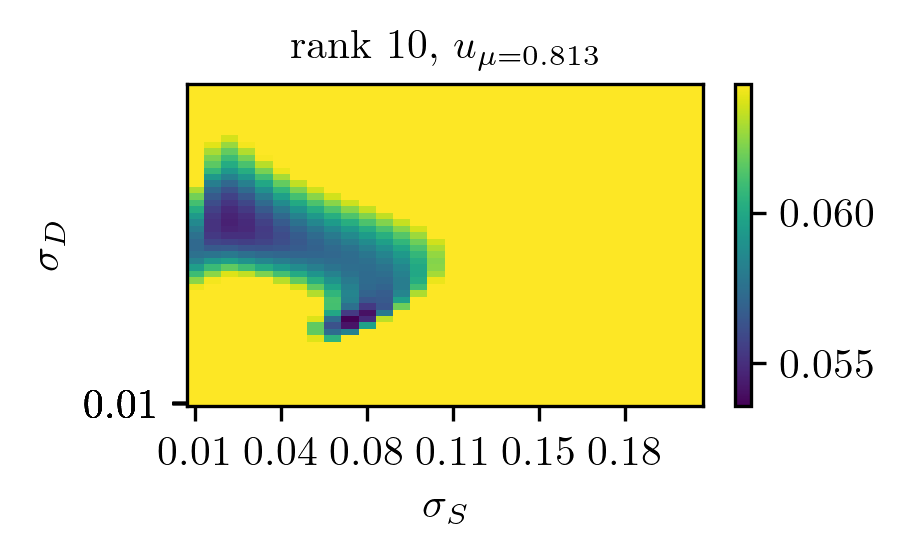

0 2


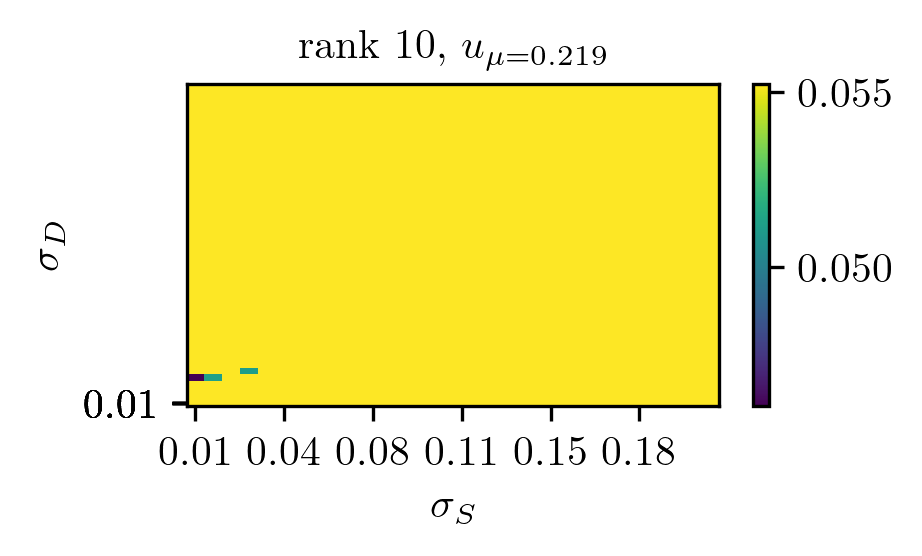

0 3


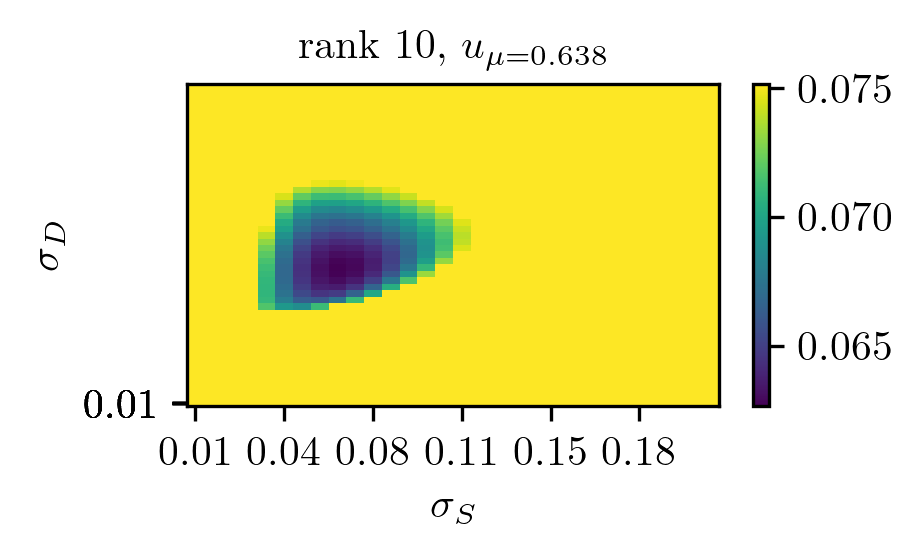

0 4


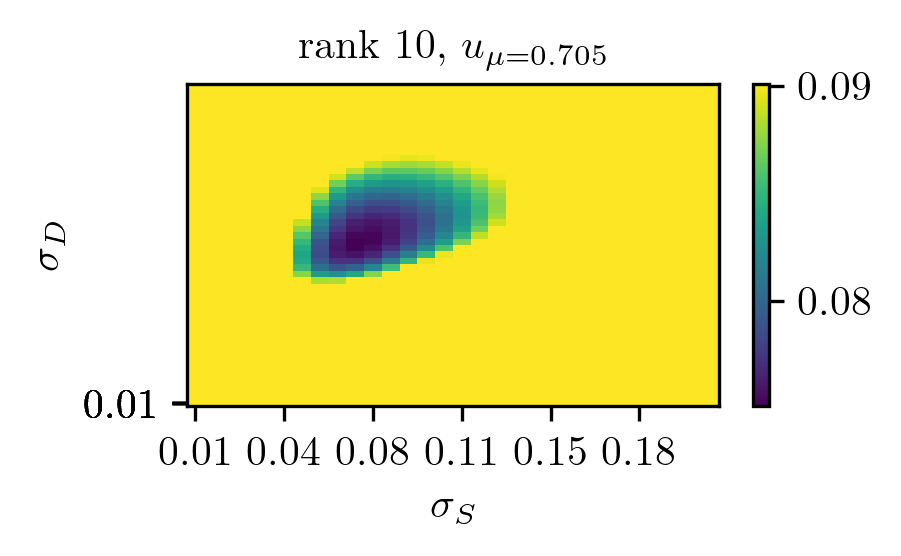

0 5


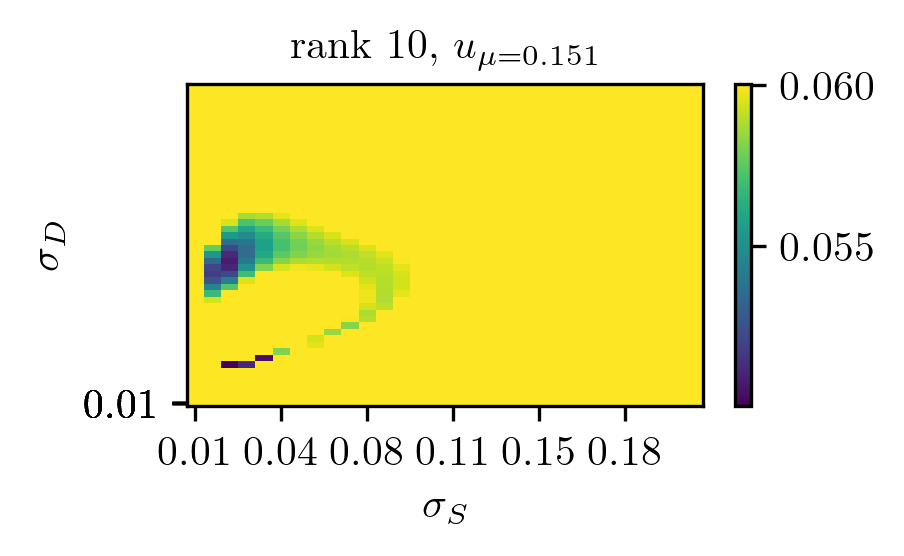

0 6


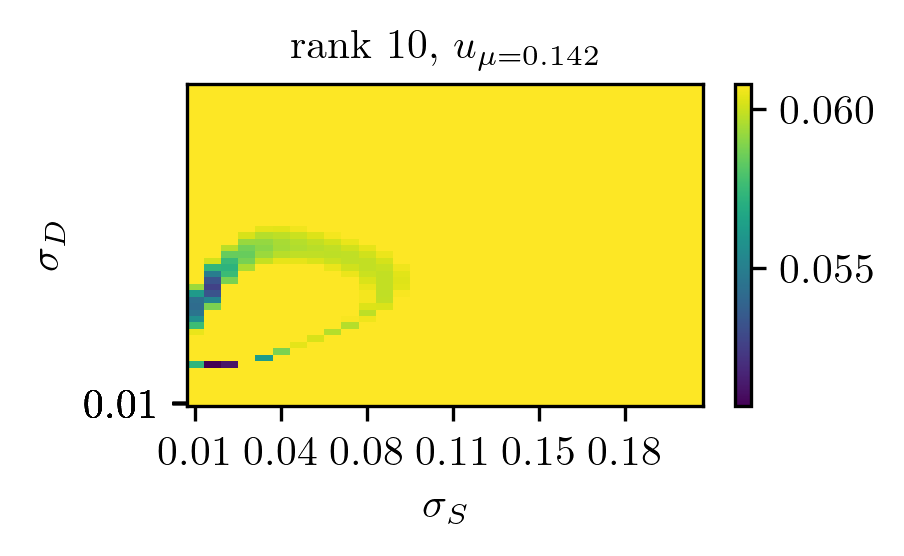

0 7


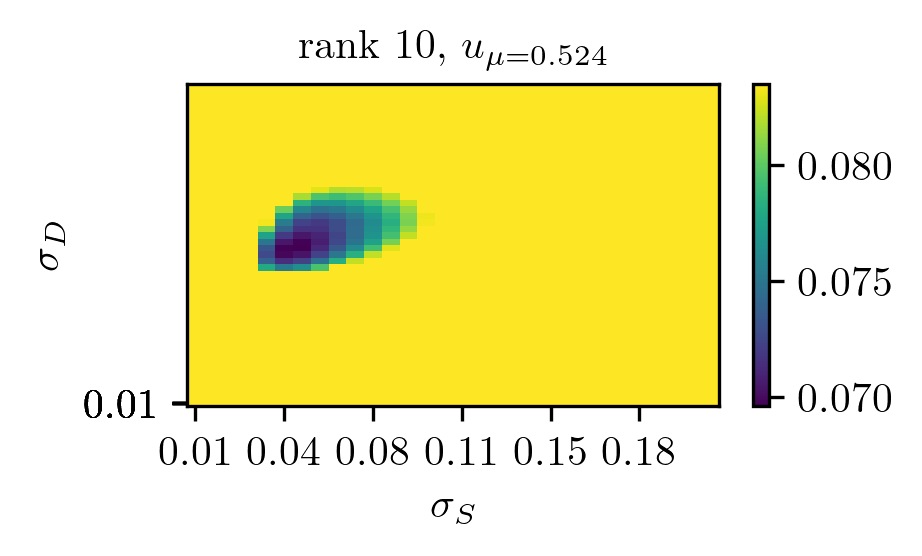

0 8


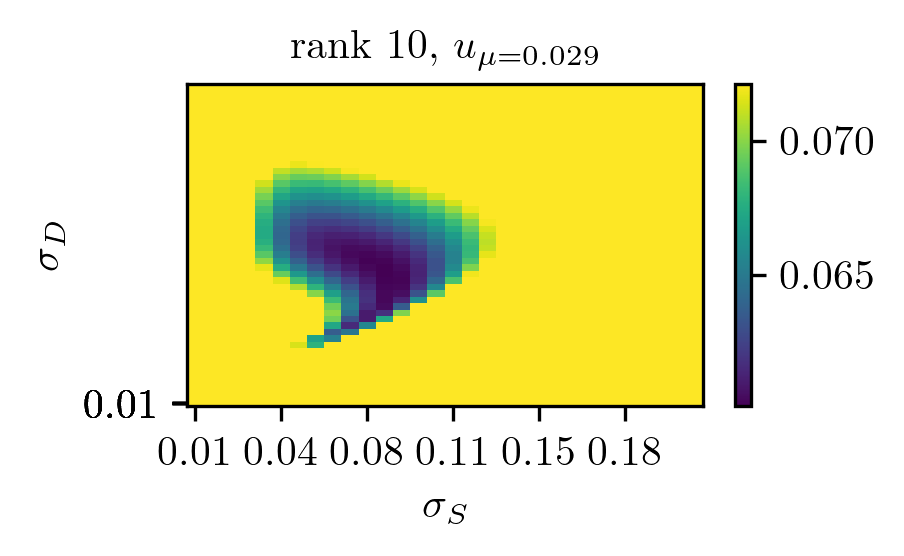

0 9


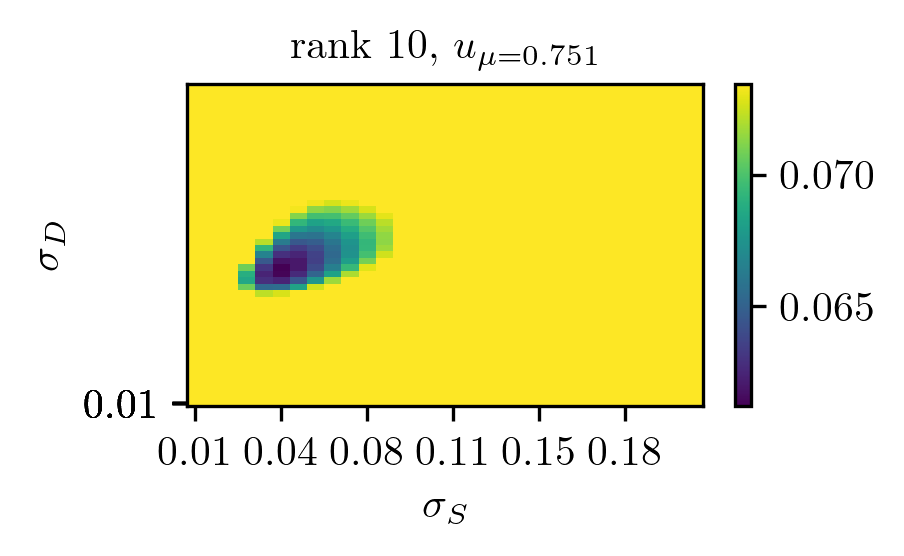

0 [0.77092681] 0.0
1 [0.87495919] 0.0
2 [0.98420059] 0.0
3 [0.57616601] 0.0
4 [0.78096172] 0.0
5 [0.87815266] 0.0
6 [0.41079037] 0.0
7 [0.42615779] 0.0
8 [0.93238653] 0.0
9 [0.77420334] 0.0
10 [0.71266697] 0.0
11 [0.35646591] 0.0
12 [0.63733865] 0.0
13 [0.88004379] 0.0
14 [0.45684711] 0.0
15 [0.89308824] 0.0
16 [0.13481578] 0.0
17 [0.49564956] 0.0
18 [0.7529567] 0.0
19 [0.00712763] 0.0
0 [0.59157677] 0.0
1 [0.05117507] 0.0
2 [0.71856808] 0.0
3 [0.87343417] 0.0
4 [0.1872581] 0.0
5 [0.2909454] 0.0
6 [0.613858] 0.0
7 [0.84335392] 0.0
8 [0.95412294] 0.0
9 [0.45661934] 0.0
1 0


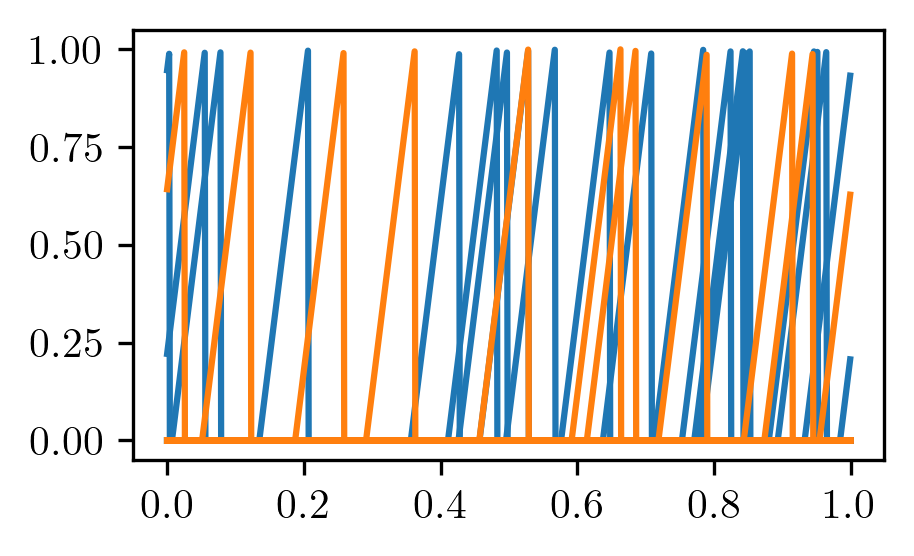

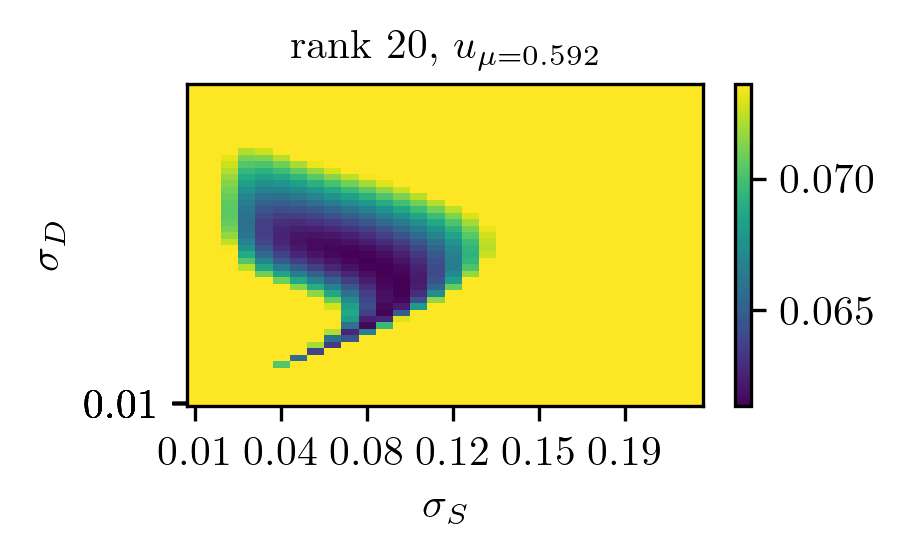

1 1


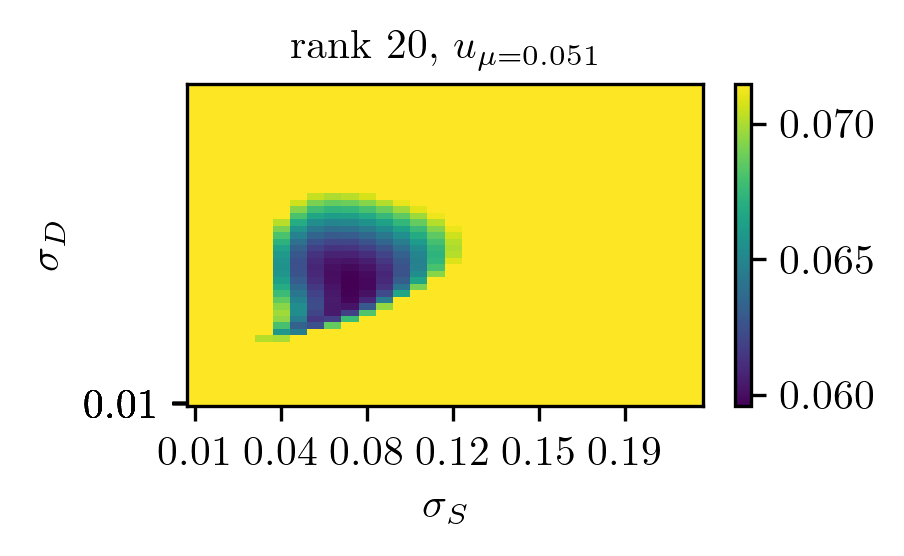

1 2


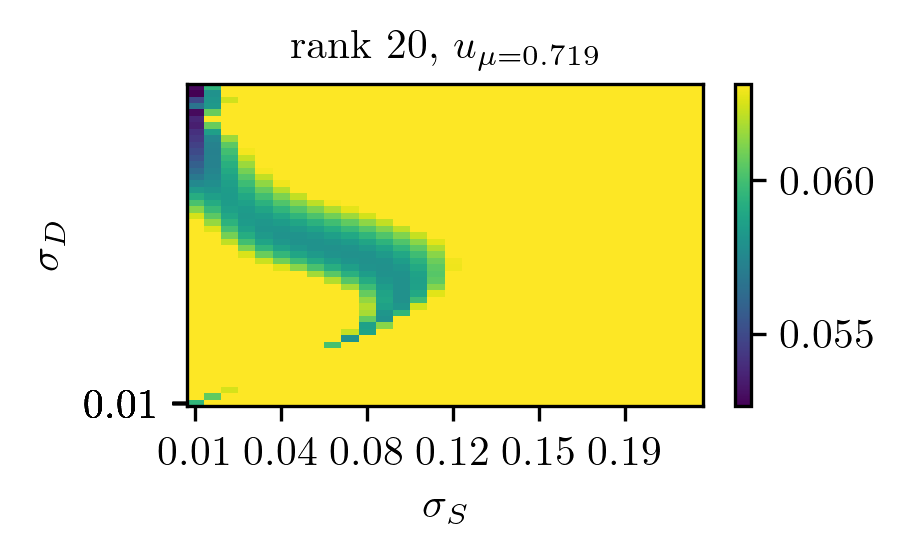

1 3


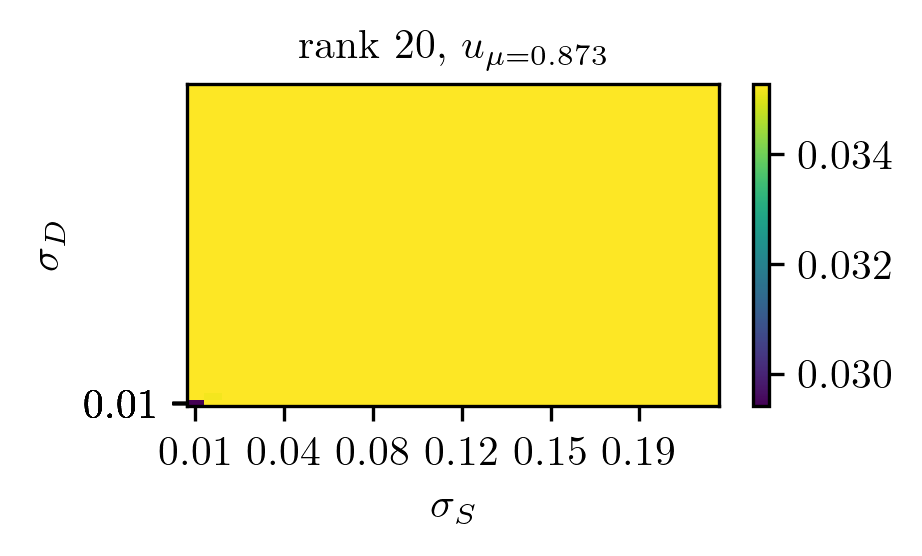

1 4


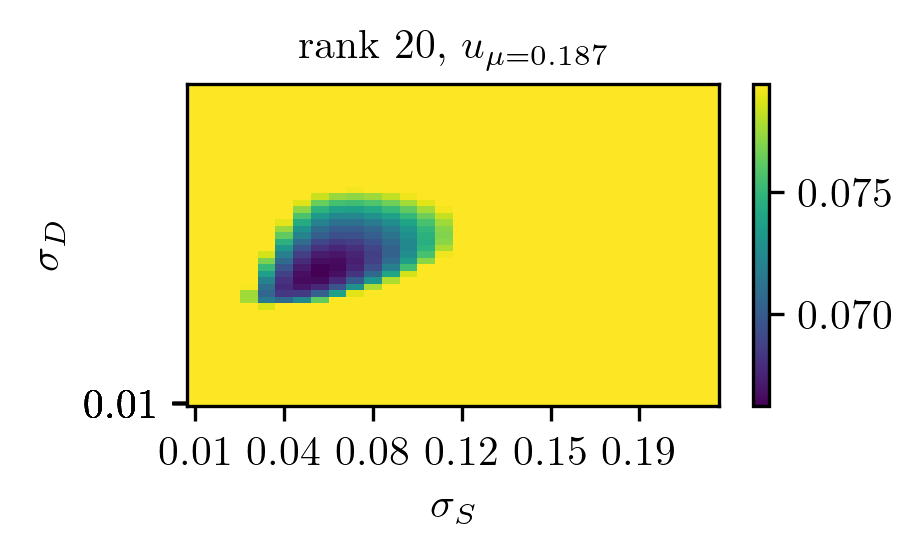

1 5


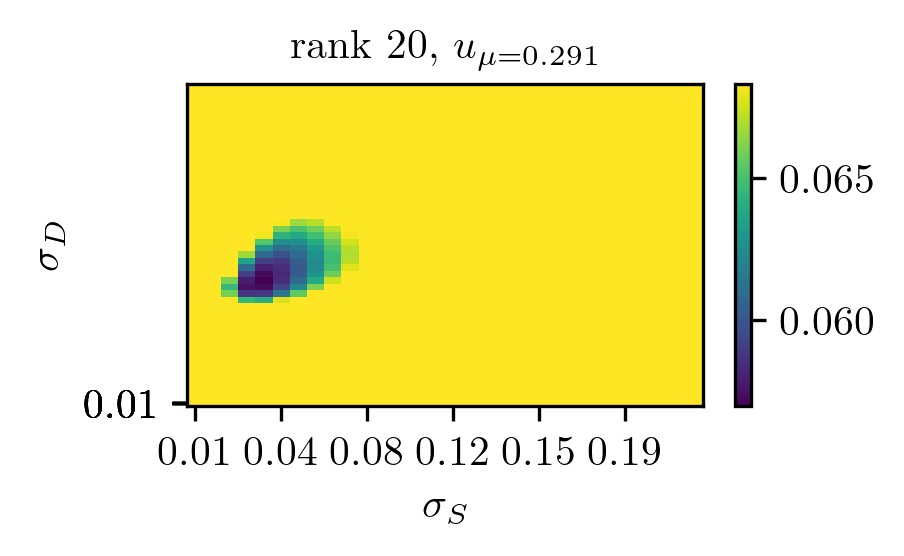

1 6


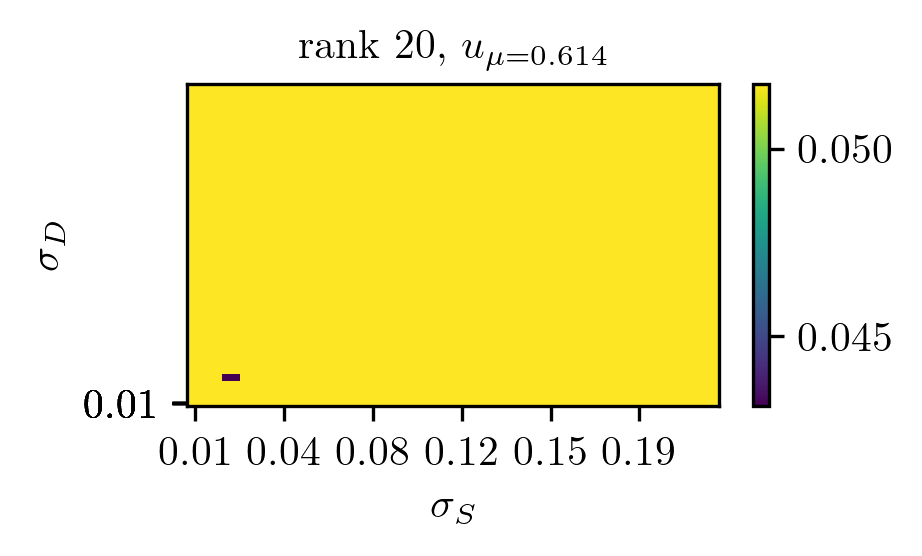

1 7


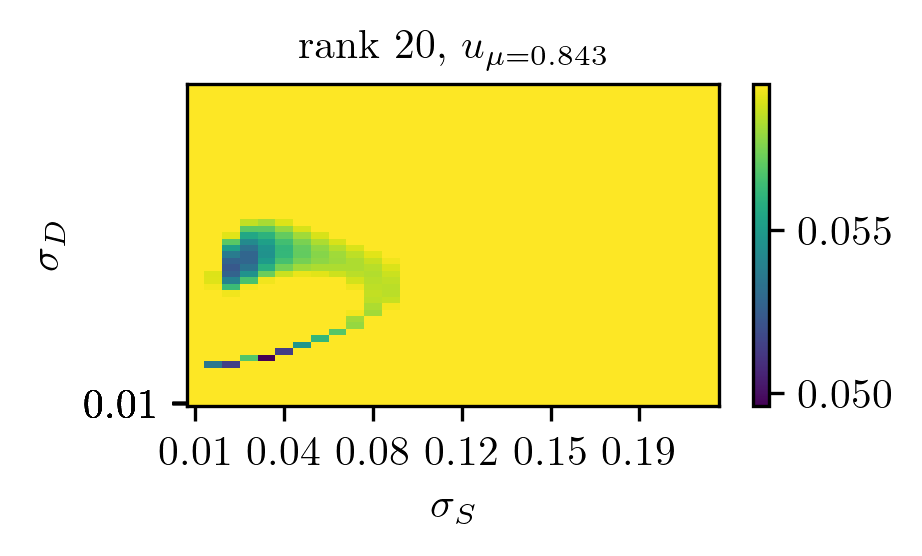

1 8


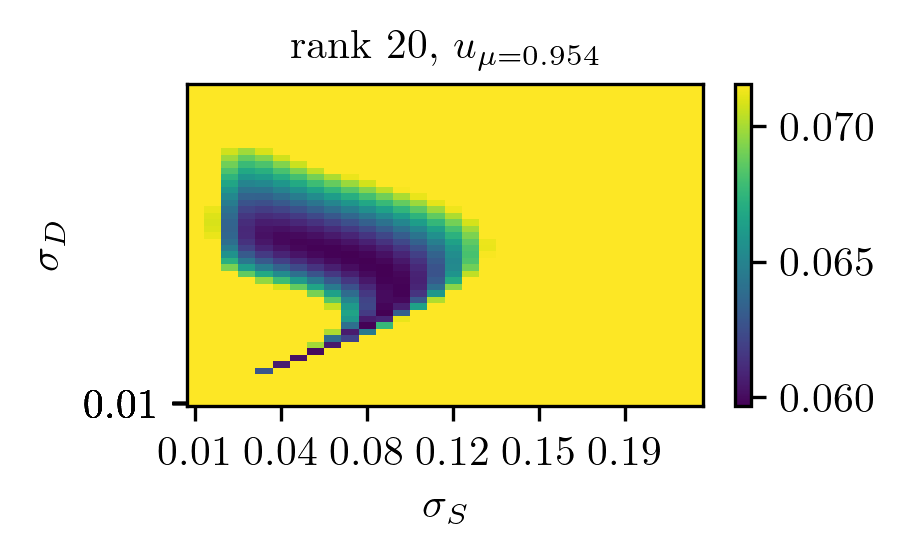

1 9


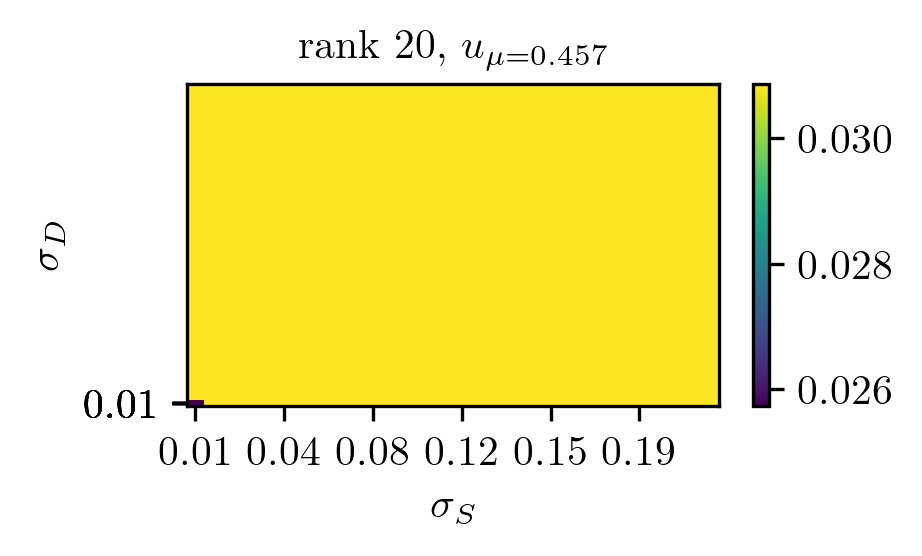

0 [0.04888724] 0.0
1 [0.29088464] 0.0
2 [0.86803025] 0.0
3 [0.84150063] 0.0
4 [0.79073503] 0.0
5 [0.54214246] 0.0
6 [0.65694652] 0.0
7 [0.18455042] 0.0
8 [0.79027009] 0.0
9 [0.11464659] 0.0
10 [0.14480558] 0.0
11 [0.05666589] 0.0
12 [0.11552266] 0.0
13 [0.41395263] 0.0
14 [0.62844079] 0.0
15 [0.6614234] 0.0
16 [0.61288287] 0.0
17 [0.18094428] 0.0
18 [0.07027295] 0.0
19 [0.03889198] 0.0
20 [0.98586767] 0.0
21 [0.19389528] 0.0
22 [0.00544592] 0.0
23 [0.96345977] 0.0
24 [0.16319605] 0.0
25 [0.7829271] 0.0
26 [0.65322766] 0.0
27 [0.54106693] 0.0
28 [0.3673565] 0.0
29 [0.03227147] 0.0
0 [0.31045962] 0.0
1 [0.86711372] 0.0
2 [0.92564746] 0.0
3 [0.34537942] 0.0
4 [0.17798843] 0.0
5 [0.62300224] 0.0
6 [0.22929453] 0.0
7 [0.27244201] 0.0
8 [0.92269275] 0.0
9 [0.046862] 0.0
2 0


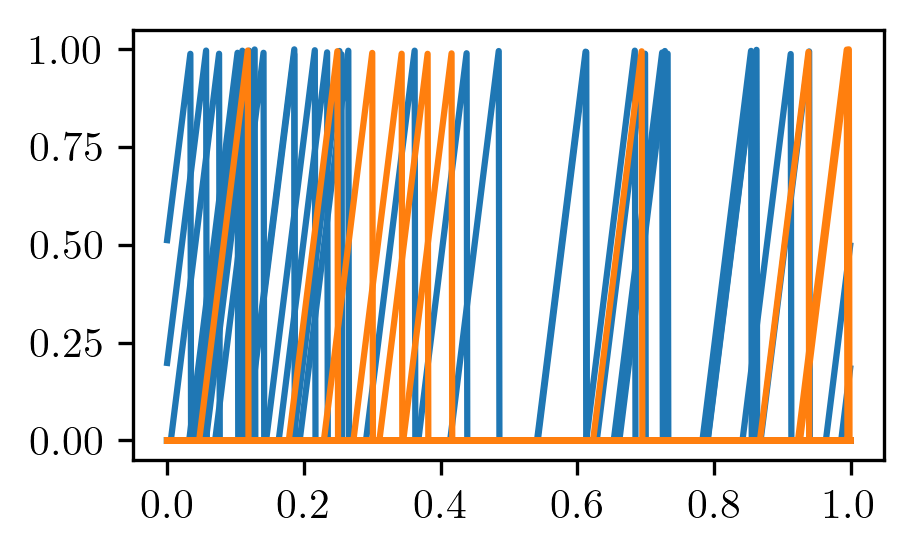

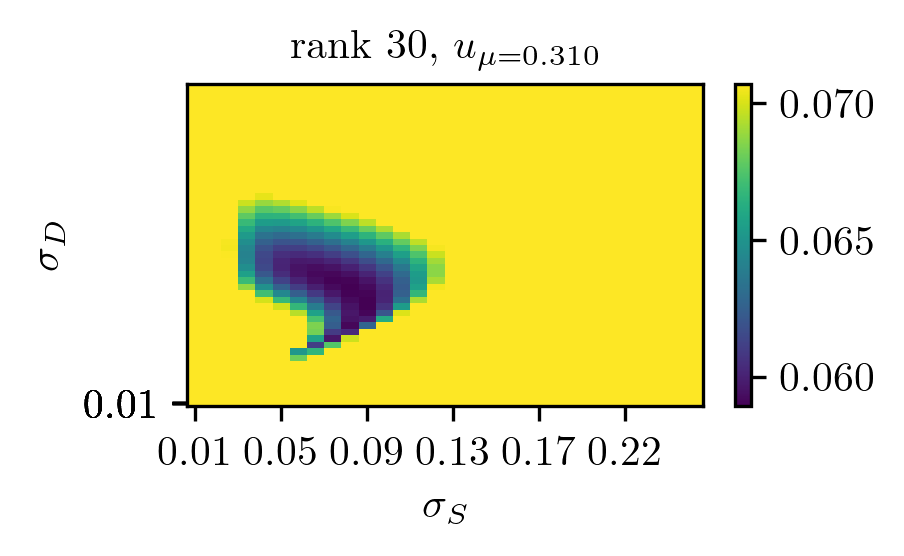

2 1


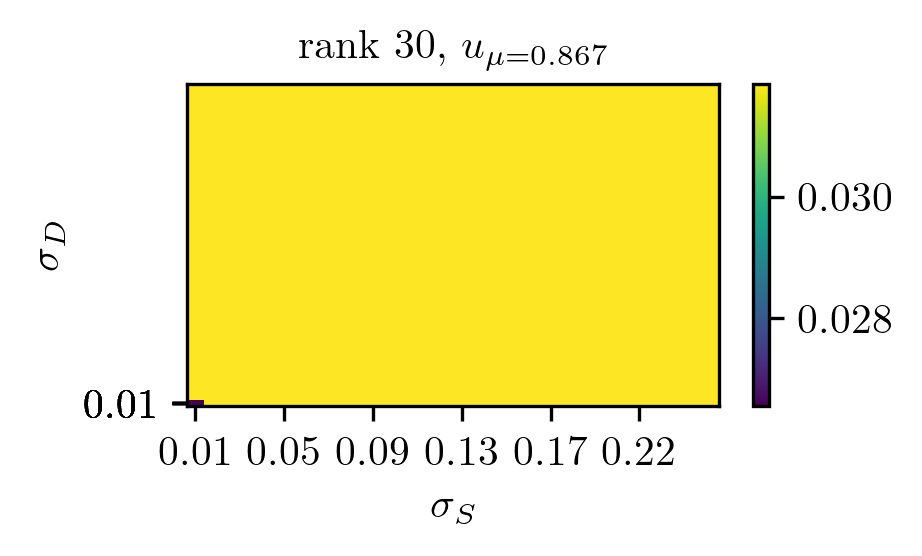

2 2


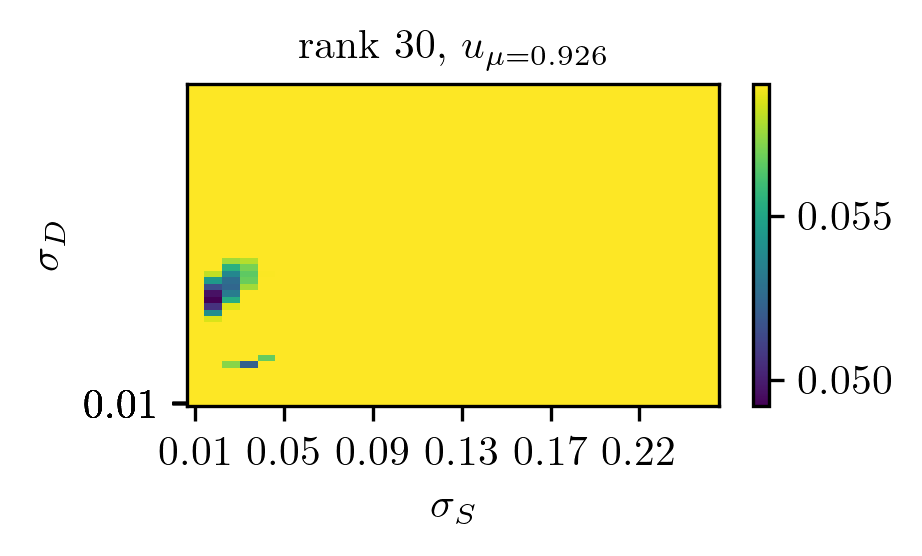

2 3


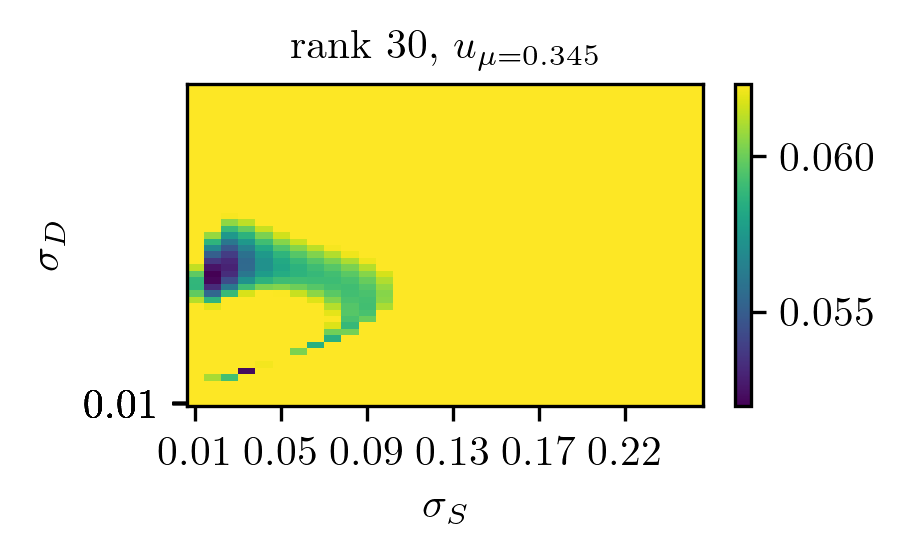

2 4


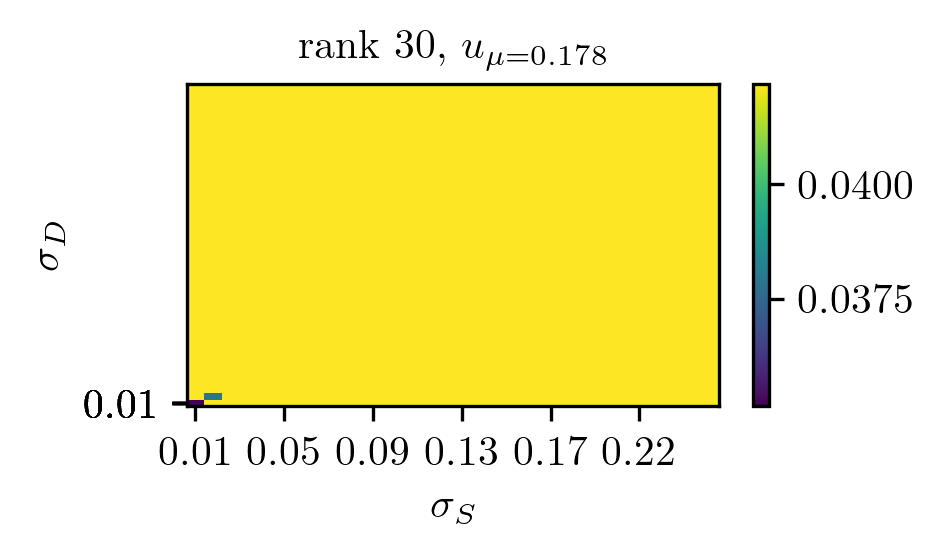

2 5


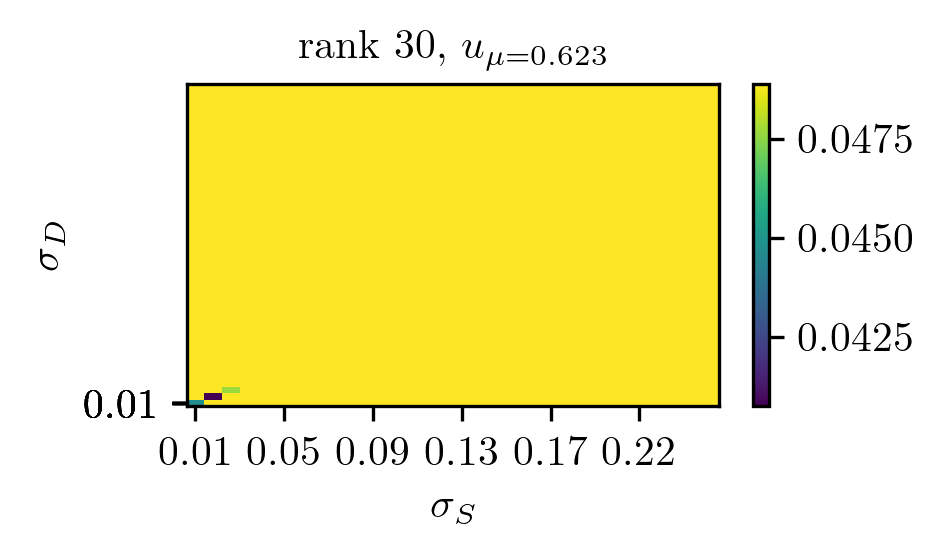

2 6


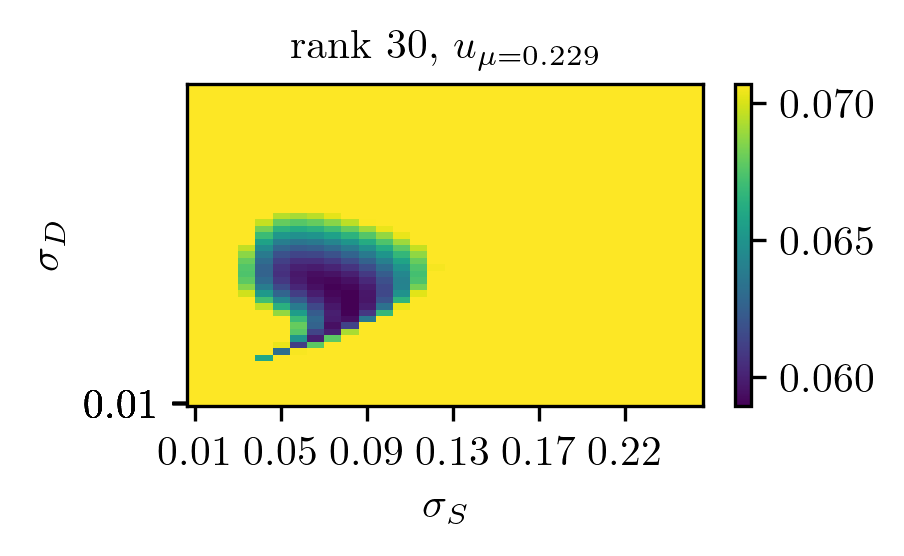

2 7


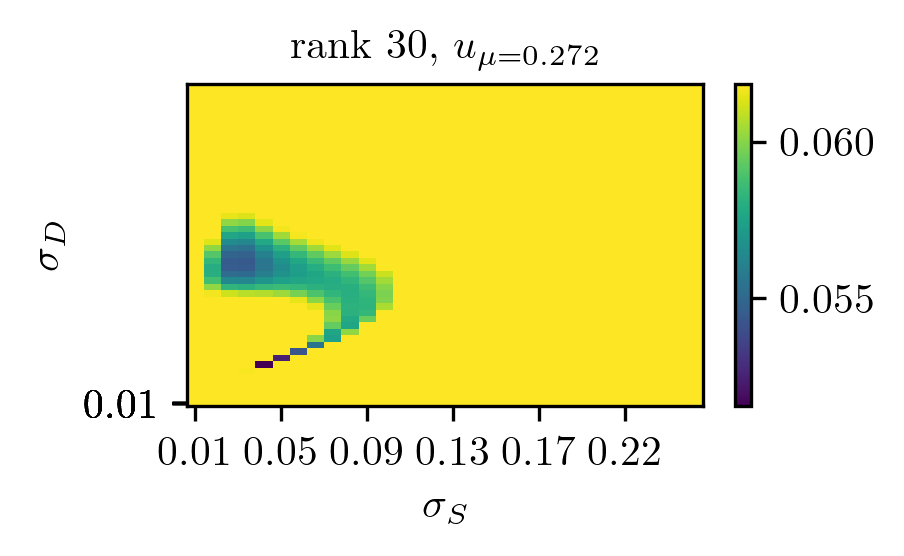

2 8


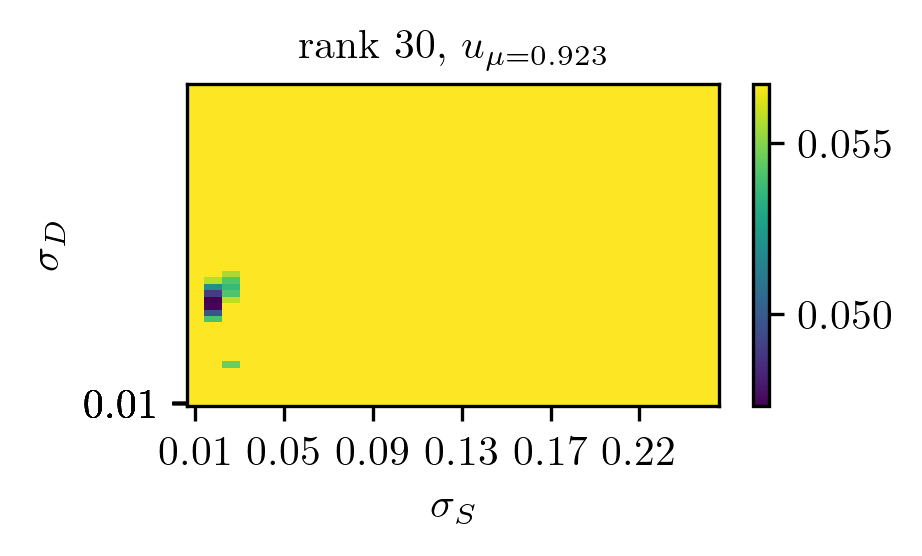

2 9


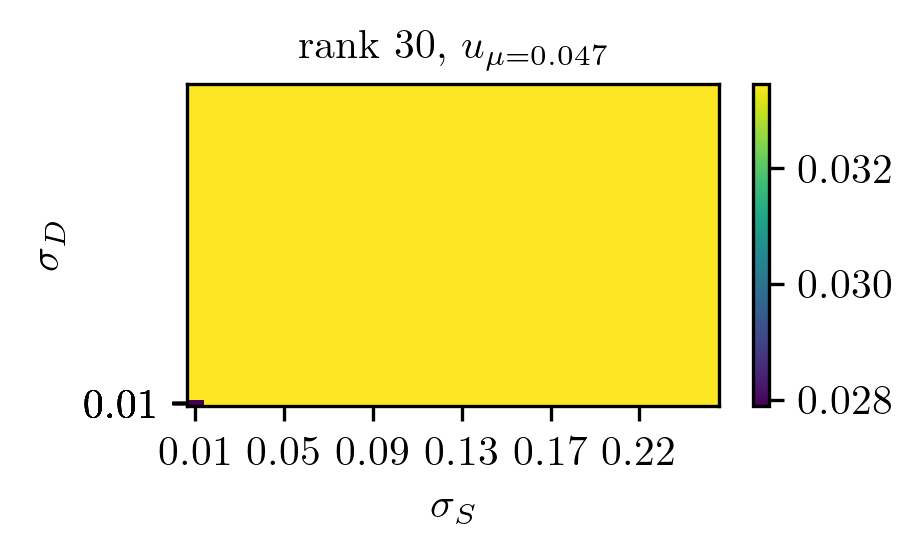

0 [0.17035749] 0.0
1 [0.16821213] 0.0
2 [0.3298421] 0.0
3 [0.98503153] 0.0
4 [0.21172721] 0.0
5 [0.12137795] 0.0
6 [0.25465812] 0.0
7 [0.88723655] 0.0
8 [0.42953441] 0.0
9 [0.06258411] 0.0
10 [0.71333585] 0.0
11 [0.13011588] 0.0
12 [0.77125806] 0.0
13 [0.79463314] 0.0
14 [0.22044132] 0.0
15 [0.98693744] 0.0
16 [0.38421674] 0.0
17 [0.30421665] 0.0
18 [0.06493501] 0.0
19 [0.12842963] 0.0
20 [0.0678881] 0.0
21 [0.79241976] 0.0
22 [0.82803533] 0.0
23 [0.93344924] 0.0
24 [0.3853386] 0.0
25 [0.70020775] 0.0
26 [0.74542598] 0.0
27 [0.87668063] 0.0
28 [0.48283529] 0.0
29 [0.16843224] 0.0
30 [0.76636655] 0.0
31 [0.22592144] 0.0
32 [0.06110347] 0.0
33 [0.29909671] 0.0
34 [0.7178693] 0.0
35 [0.34277222] 0.0
36 [0.71702532] 0.0
37 [0.20594413] 0.0
38 [0.77438211] 0.0
39 [0.28961058] 0.0
40 [0.10308508] 0.0
41 [0.51557067] 0.0
42 [0.57740368] 0.0
43 [0.69203251] 0.0
44 [0.68780414] 0.0
45 [0.81190978] 0.0
46 [0.35331178] 0.0
47 [0.62690594] 0.0
48 [0.64232644] 0.0
49 [0.58139238] 0.0
0 [0.47003241]

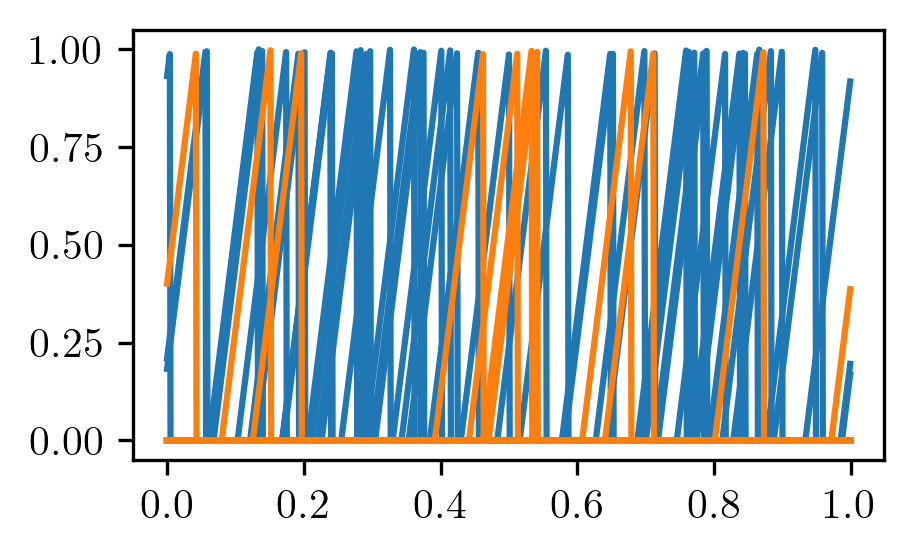

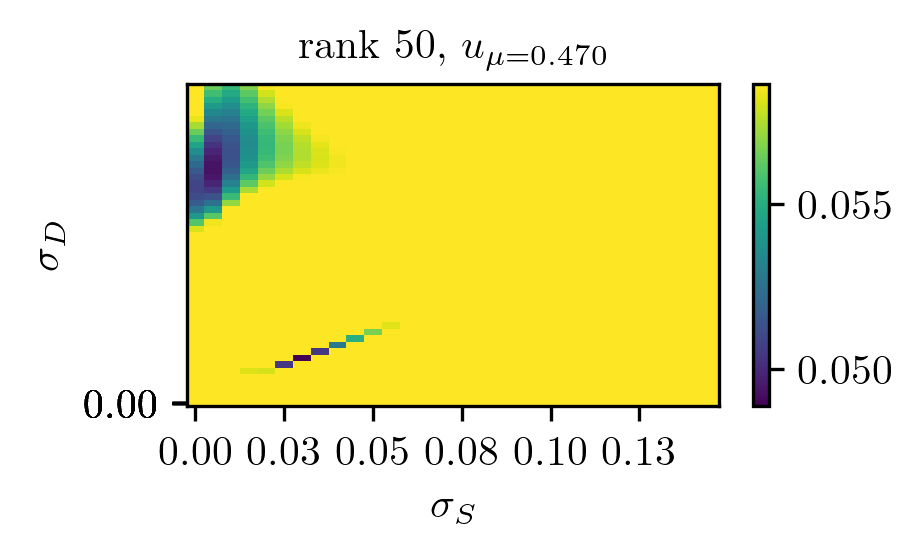

3 1


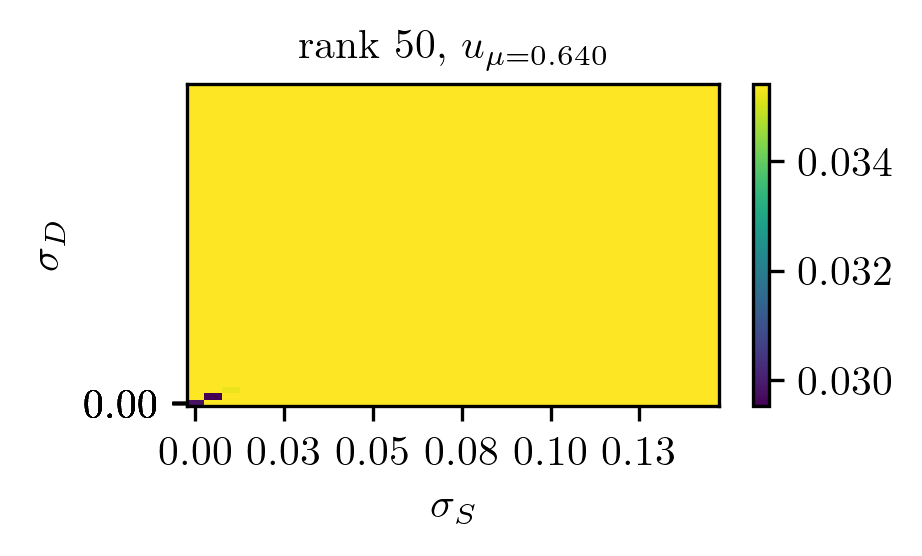

3 2


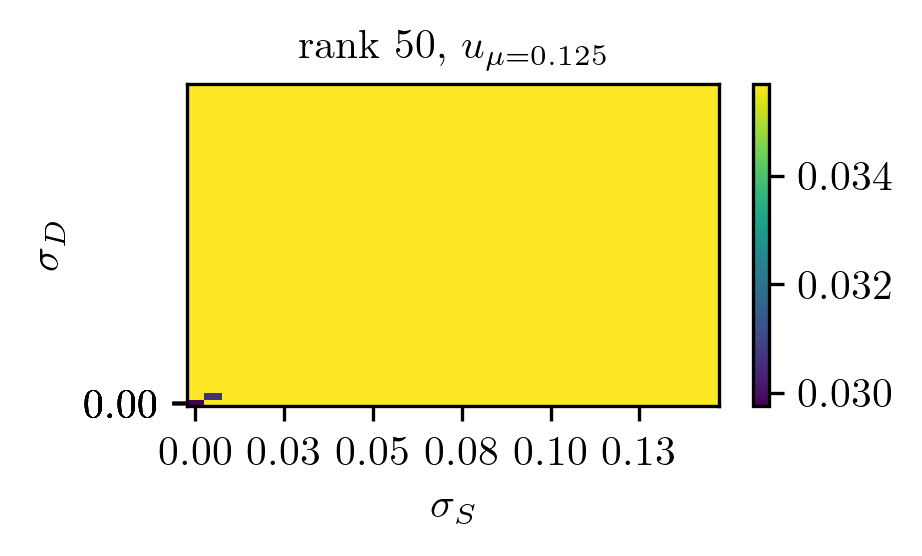

3 3


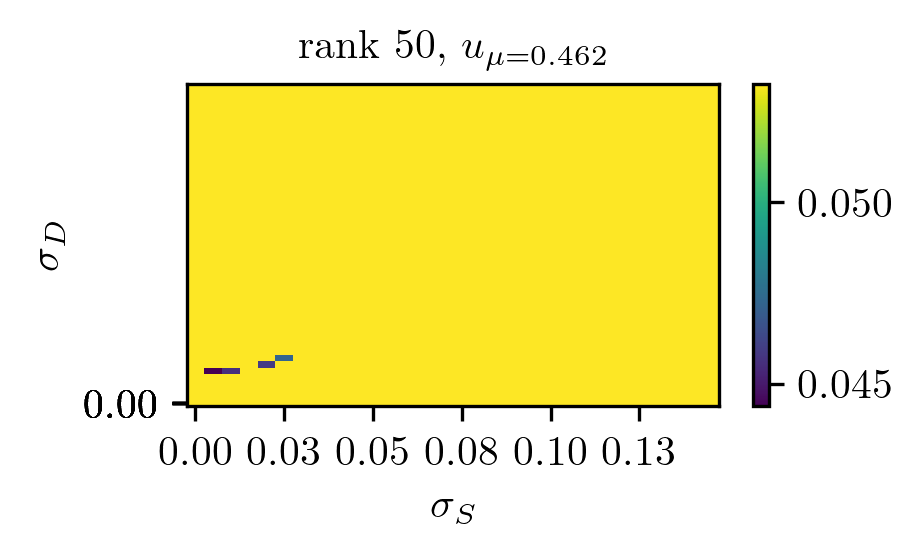

3 4


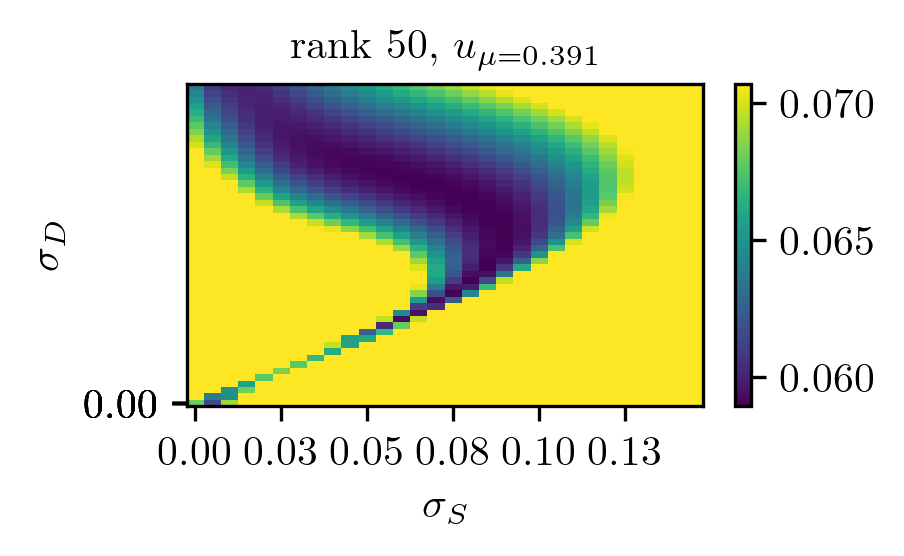

3 5


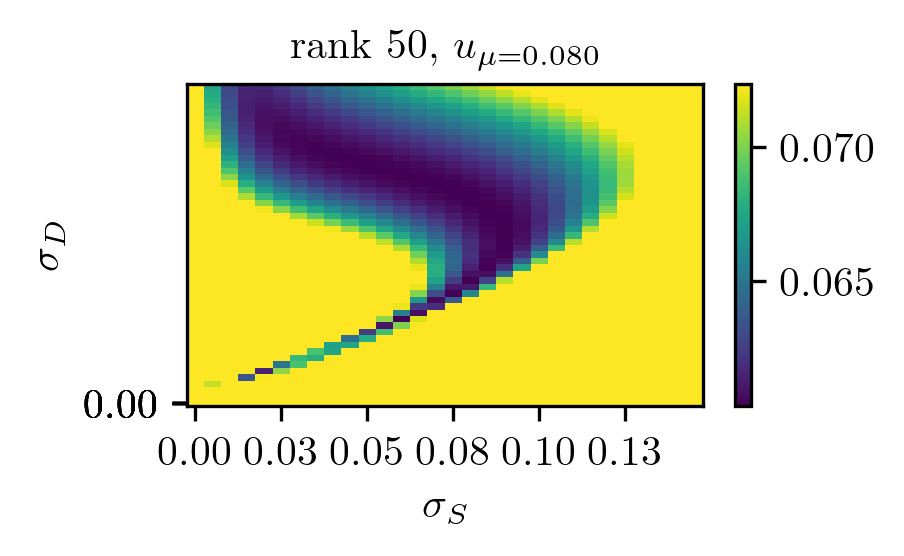

3 6


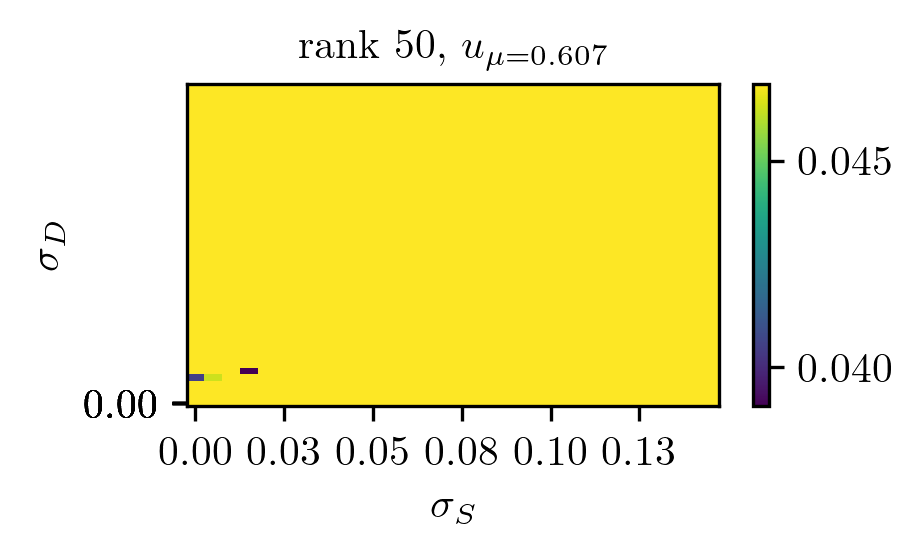

3 7


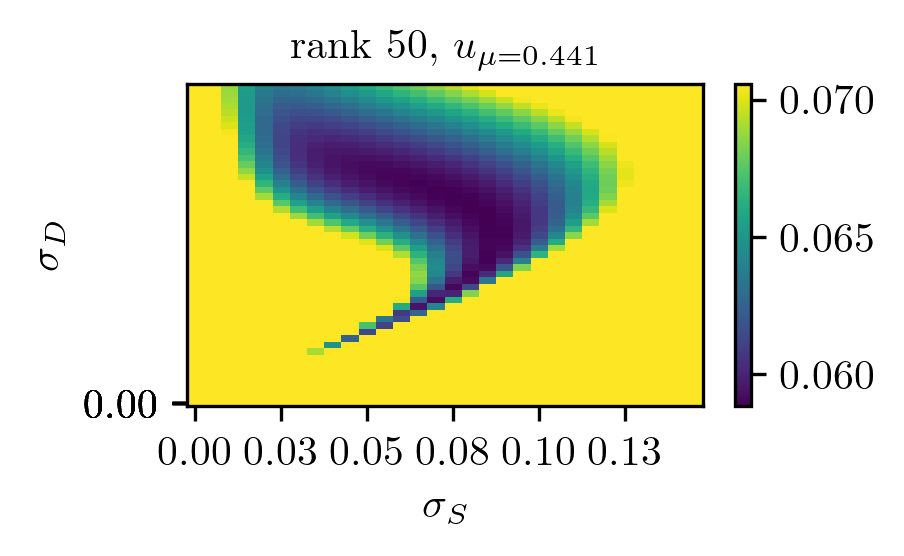

3 8


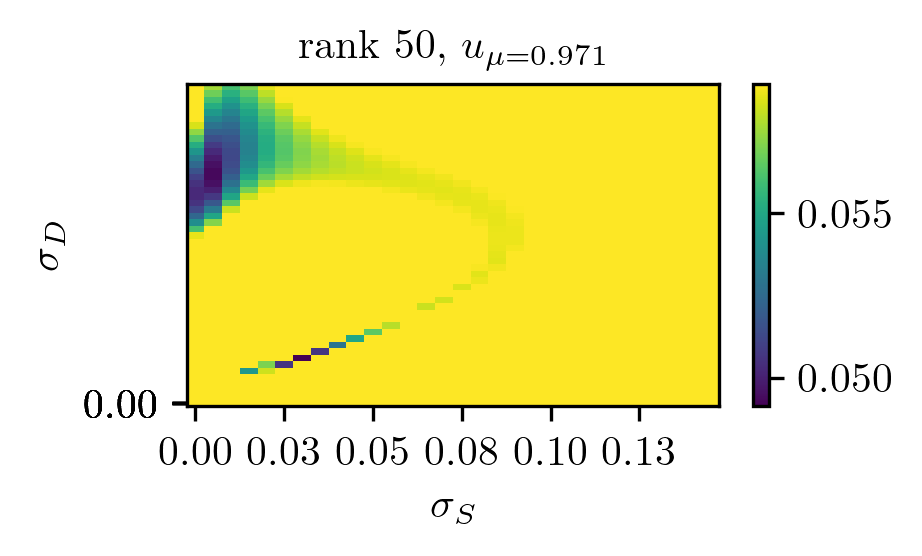

3 9


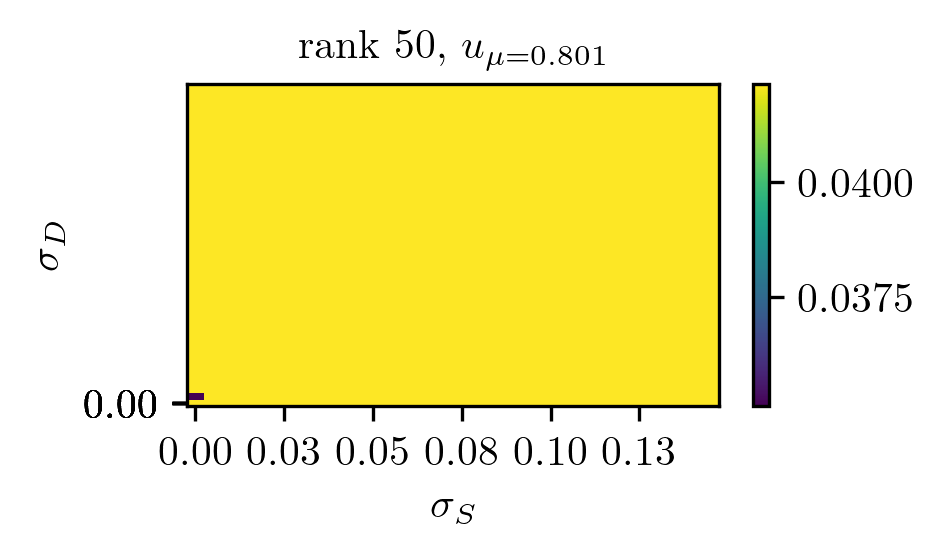

0 [0.15173079] 0.0
1 [0.4900586] 0.0
2 [0.34672087] 0.0
3 [0.57240539] 0.0
4 [0.72009109] 0.0
5 [0.8272587] 0.0
6 [0.9520735] 0.0
7 [0.93684564] 0.0
8 [0.59346263] 0.0
9 [0.23577575] 0.0
10 [0.49294943] 0.0
11 [0.11244532] 0.0
12 [0.93356061] 0.0
13 [0.58390648] 0.0
14 [0.71750371] 0.0
15 [0.19736924] 0.0
16 [0.50841996] 0.0
17 [0.22102818] 0.0
18 [0.34402941] 0.0
19 [0.84293703] 0.0
20 [0.02239375] 0.0
21 [0.4547236] 0.0
22 [0.69916246] 0.0
23 [0.01944235] 0.0
24 [0.64684623] 0.0
25 [0.31278191] 0.0
26 [0.45006954] 0.0
27 [0.61710387] 0.0
28 [0.75674842] 0.0
29 [0.30557667] 0.0
30 [0.63614713] 0.0
31 [0.41946784] 0.0
32 [0.85936718] 0.0
33 [0.15932445] 0.0
34 [0.30995315] 0.0
35 [0.36331512] 0.0
36 [0.64713053] 0.0
37 [0.44892519] 0.0
38 [0.61489785] 0.0
39 [0.0161287] 0.0
40 [0.27524879] 0.0
41 [0.2317285] 0.0
42 [0.652182] 0.0
43 [0.55408595] 0.0
44 [0.73139726] 0.0
45 [0.6247873] 0.0
46 [0.75624075] 0.0
47 [0.79997038] 0.0
48 [0.89409645] 0.0
49 [0.08338394] 0.0
50 [0.4422648] 0.0


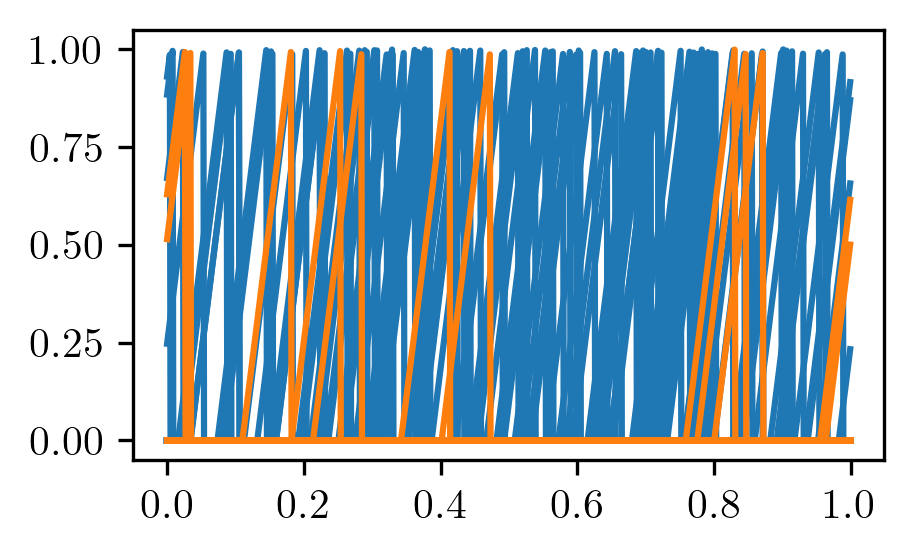

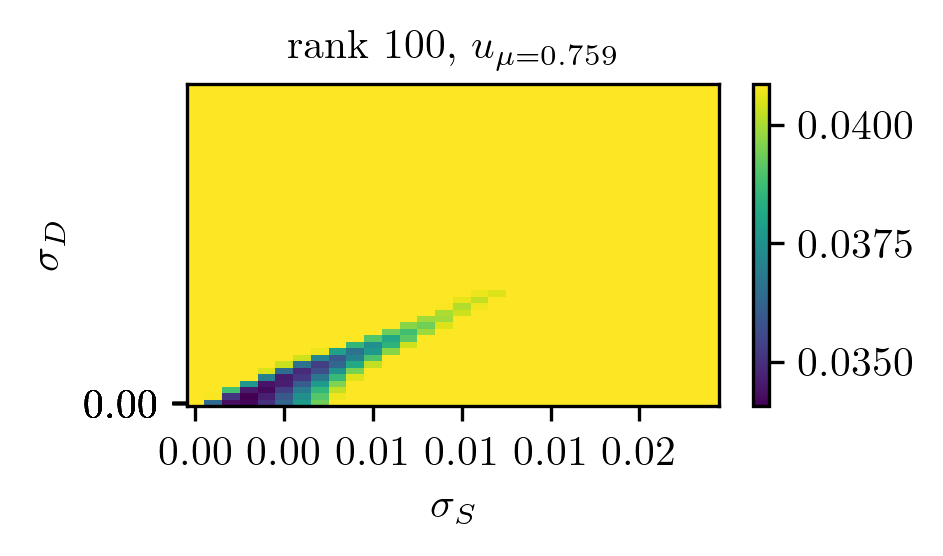

4 1


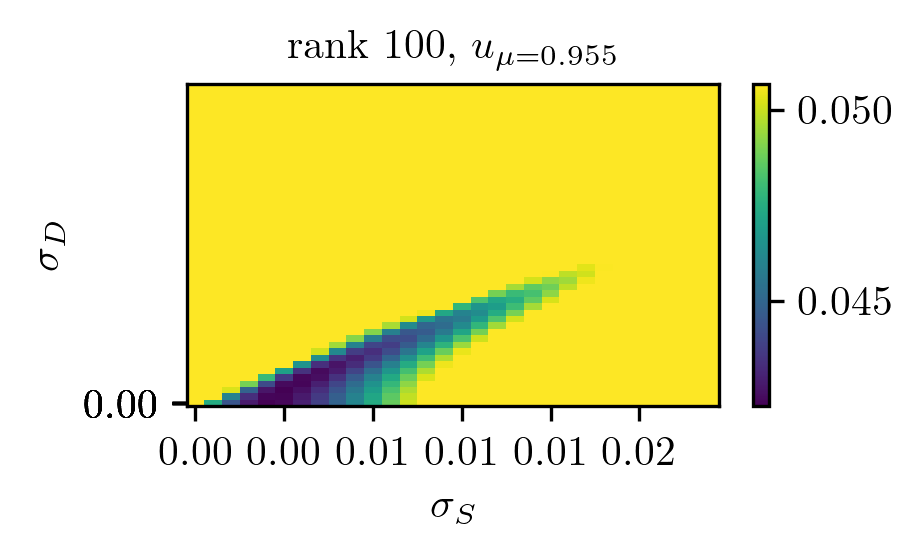

4 2


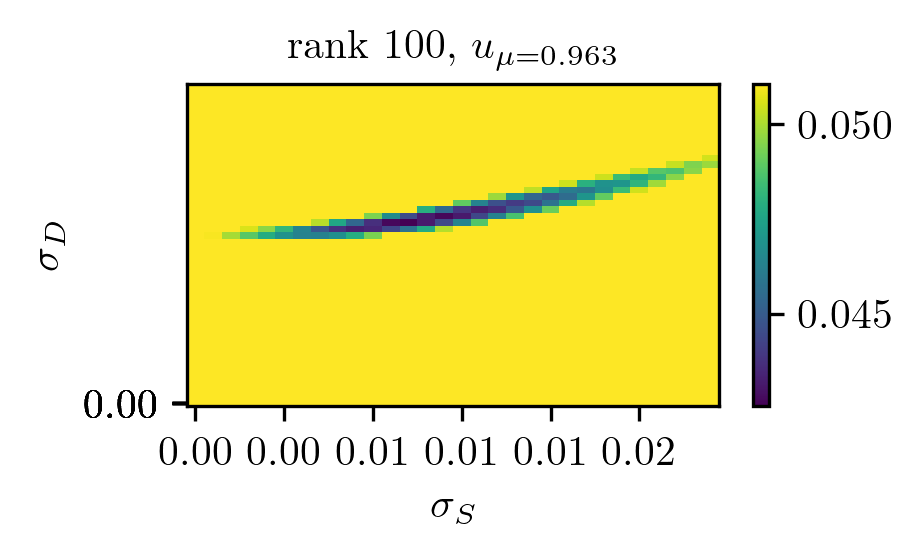

4 3


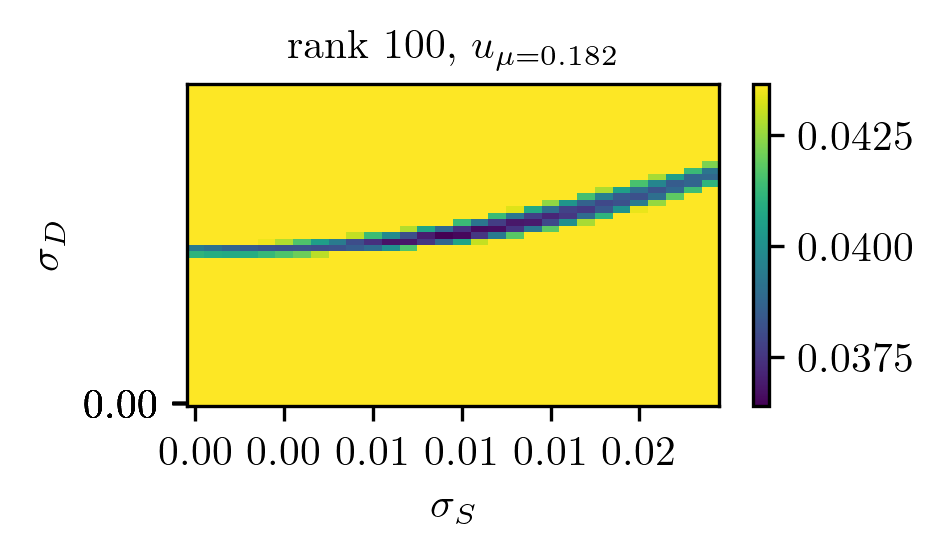

4 4


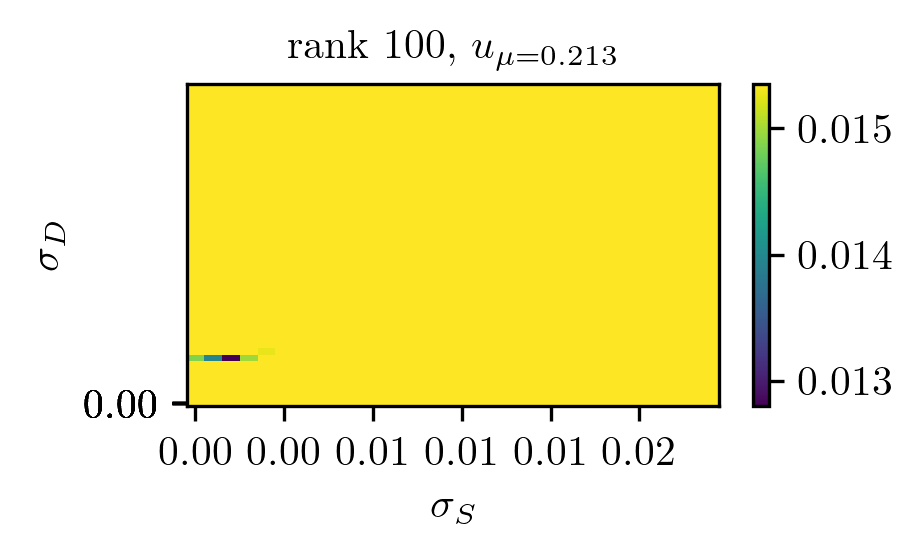

4 5


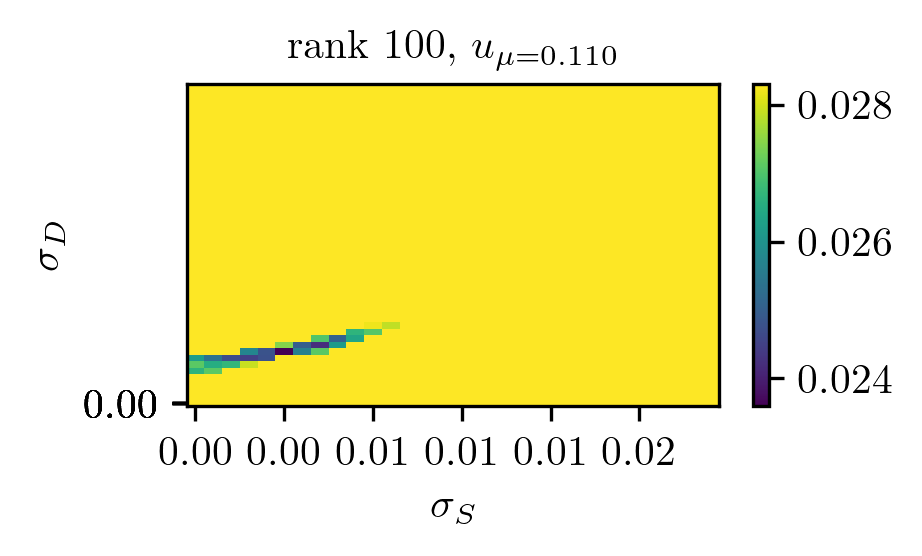

4 6


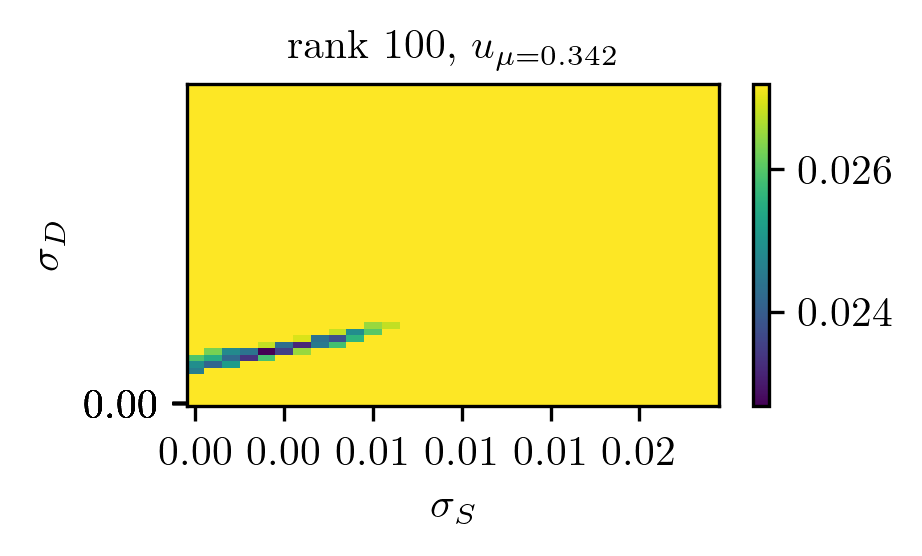

4 7


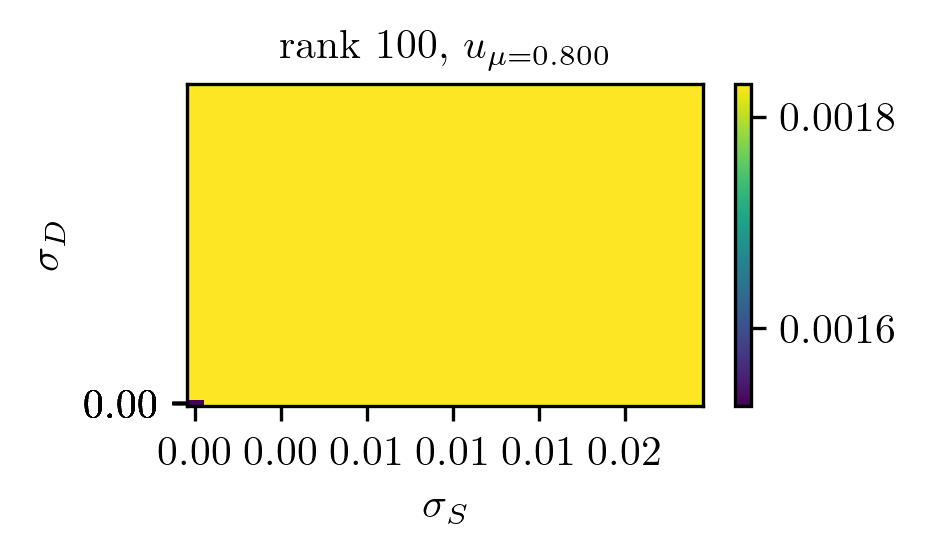

4 8


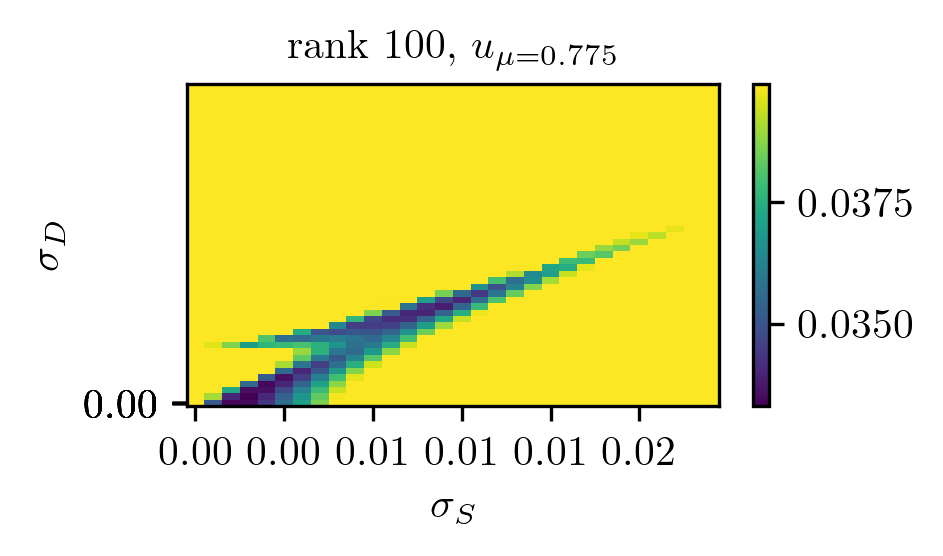

4 9


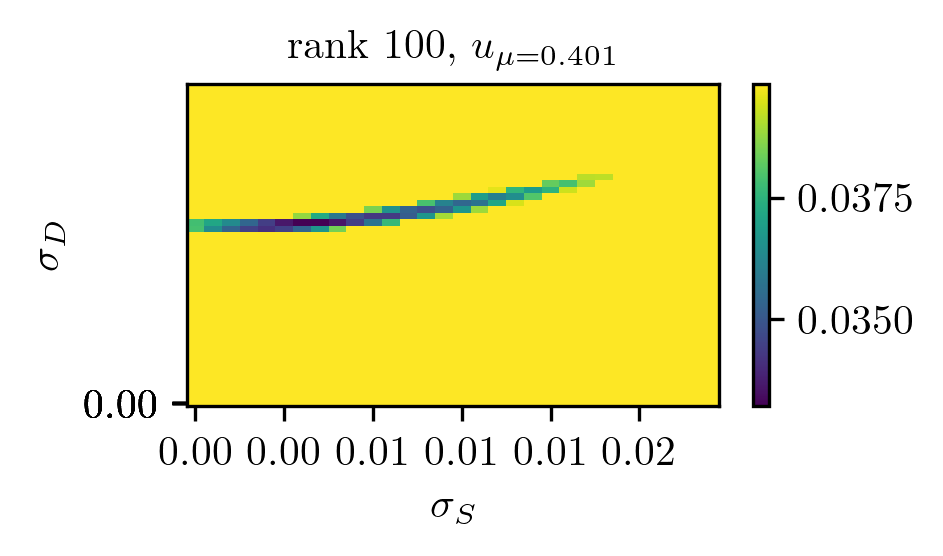

In [7]:
for i, rank in enumerate([10, 20, 30, 50, 100]):
    mu_train, mu_test = mu_train_rankwise[i], mu_test_rankwise[i]
    X_train, X_train_s = get_data_rw(mu_train, **case)
    X_test, X_test_s = get_data_rw(mu_test, **case)
    for m in range(len(X_train)):
        plt.plot(case["x"], X_train[m], "C0-")
        print(m, mu_train[m], np.min(X_train[m]))
    for n in range(len(X_test)):
        print(n, mu_test[n], np.min( X_test[n]))
        plt.plot(case["x"], X_test[n], "C1-")

    for j, mu in enumerate(mu_test):
        print(i, j)
        #plt.imshow(errors[i, j])
        fig, ax = plt.subplots()
        mesh = ax.pcolormesh(sigma_S[i, j], sigma_D[i, j], errors[i, j], shading=None, cmap='viridis', vmin=np.min(errors[i, j]), vmax=np.min(errors[i, j])*1.2)
        ax.set_xticks(sigma_S[i, j, ::5, 0])
        ax.set_yticks(sigma_D[i, j, ::5, 0])
        ax.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
        ax.set_xlabel(r"$\sigma_S$")
        ax.set_ylabel(r"$\sigma_D$")
        
        plt.title("rank "+str(rank)+r", $u_{\mu"+"={:.3f}".format(mu[0])+r"}$")
        cbar = plt.colorbar(mesh, ax=ax)
        plt.show()